# ICMS 150 (April 4)

- **Combined_Pattern_Registrations.pkl**: including electrical stimulation pattern informations, the same format as the one I shared before with you.
- **All_Shank_Spk_Vecs.npy**: spiking events from each neuron. The same format as previous. Sampling frequency: 30K
- **VStim_Onset_TS.npy**: the onset timestamps of each visual stimulus trials. NOTE: These are recorded at a different sampling frequency, which is 1K. DO REMEMBER to align data in 2. and 3., they're not written under the same clock (due to hardware setup).
- **VStim_Labels.npy**: the orientation degree for each visual stimulus trials. Each degree should have 100 trials.


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 100 oracle samples repeating 10 times


In [233]:
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df
%load_ext autoreload
%autoreload 2


all_spikes = np.load("data/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
spikes_df = pd.DataFrame(all_spikes)  # columns auto-named from dtype fields
spikes_df.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df.drop(columns=['segment_index'], inplace=True)

pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json("data/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df = pattern_df.drop_duplicates()

visual_stim_times = np.load("data/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels = np.load("data/VStim_Labels.npy") # 1600 

visual_orientation_degs = np.sort(np.unique(visual_stim_labels))
visual_trial_df = pd.DataFrame({
    'timestamp': visual_stim_times,
    'orientation': visual_stim_labels
})
min_visual_timestamp = visual_trial_df['timestamp'].min()
max_visual_timestamp = visual_trial_df['timestamp'].max()

visual_spikes = spikes_df[(spikes_df['timestamp'] >= min_visual_timestamp) & (spikes_df['timestamp'] <= max_visual_timestamp)].copy()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [234]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
n_neurons = len(all_neuron_ids)
neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

sum_responses = []
for orientation in visual_orientation_degs:
    sum_response = np.zeros((n_neurons, N_BINS))
    for trial in range(N_VIS_TRIALS):
        trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                     (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
        if trial_spikes.empty:
            continue
        bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

        for neuron_id in trial_spikes['neuron_id'].unique():
            idx = neuron_to_idx[neuron_id]
            counts, _ = np.histogram(
                trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                bins=bin_edges,
            )
            sum_response[idx] += counts
    sum_response /= N_VIS_TRIALS  # average over trials 
    sum_responses.append(sum_response) 
sum_responses = np.array(sum_responses)       # (n_orientations, n_neurons, N_BINS)
print (sum_responses.shape)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"sum_responses shape (orient, neuron, time_bin): {sum_responses.shape}")


(16, 72, 50)
Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
sum_responses shape (orient, neuron, time_bin): (16, 72, 50)


In [235]:
sum_responses.sum(axis=2)
print (sum_responses.shape)


(16, 72, 50)


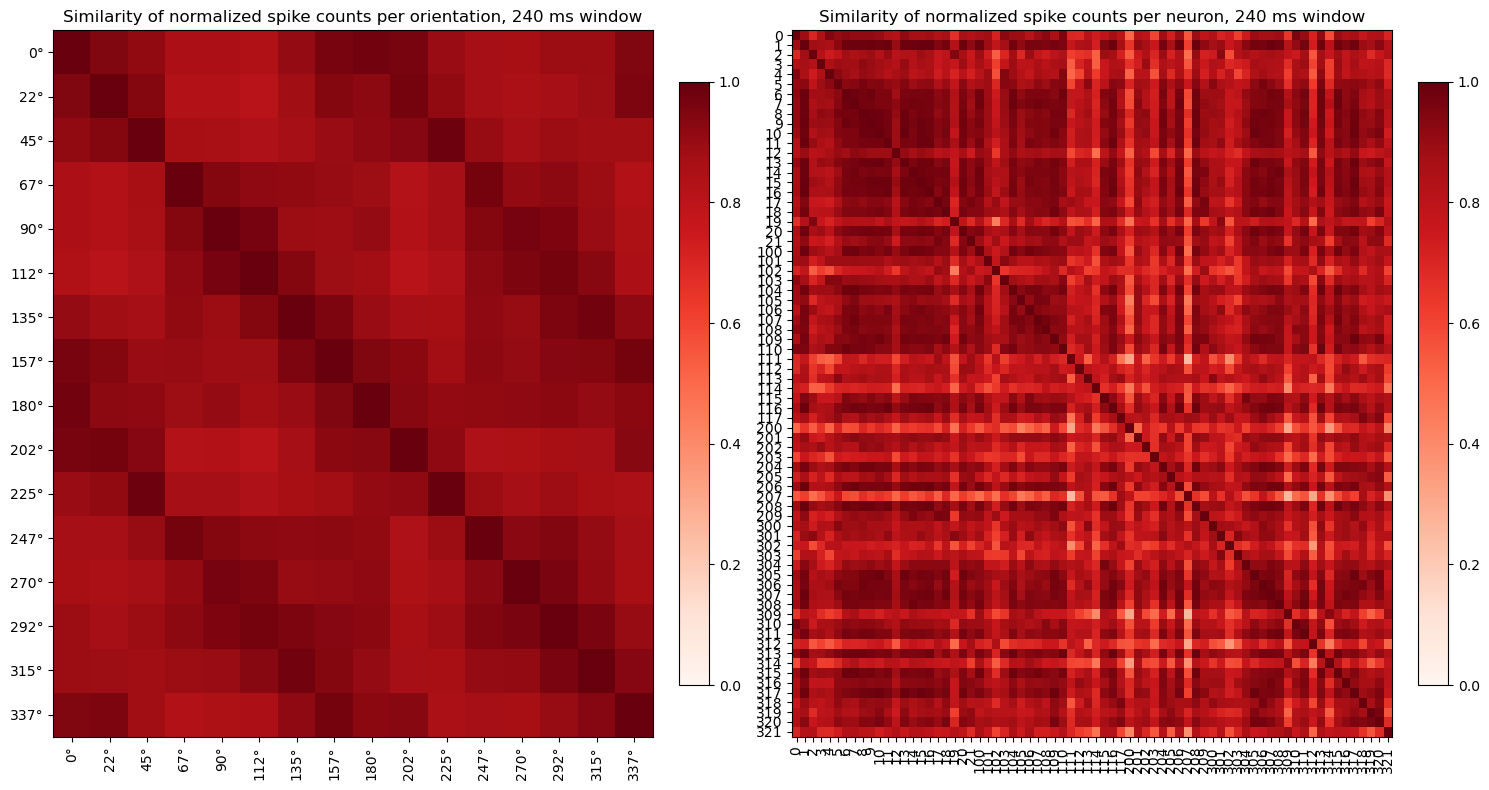

In [ ]:
from sklearn.preprocessing import normalize
window = 120 # ms
orient_total = sum_responses[:, :, :window // 10].sum(axis=2)  # (n_orient, n_neurons)
normed_ori = normalize(orient_total, norm='l2')  # each row independently        # (16, n_neurons)
sim_matrix_ori = normed_ori @ normed_ori.T     

normed_neuron = normalize(orient_total.T, norm='l2').T  # each column independently      
sim_matrix_neuron = normed_neuron.T @ normed_neuron

# print (orient_total.shape)
# sim_matrix = orient_total @ orient_total.T                    # (16, 16) cosine similarities

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
im = ax[0].imshow(sim_matrix_ori, vmin=0, vmax=1, cmap='Reds', aspect='auto')
ax[0].set_xticks(range(len(visual_orientation_degs)))
ax[0].set_yticks(range(len(visual_orientation_degs)))
ax[0].set_xticklabels([f'{int(d)}°' for d in visual_orientation_degs], rotation=90)
ax[0].set_yticklabels([f'{int(d)}°' for d in visual_orientation_degs])
ax[0].set_title(f'Similarity of normalized spike counts per orientation, {window} ms window')

ax[1].set_title(f'Similarity of normalized spike counts per neuron, {window} ms window')
ax[1].imshow(sim_matrix_neuron, vmin=0, vmax=1, cmap='Reds', aspect='auto')
ax[1].set_xticks(range(n_neurons))
ax[1].set_yticks(range(n_neurons))
ax[1].set_xticklabels(all_neuron_ids, rotation=90)
ax[1].set_yticklabels(all_neuron_ids)   
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

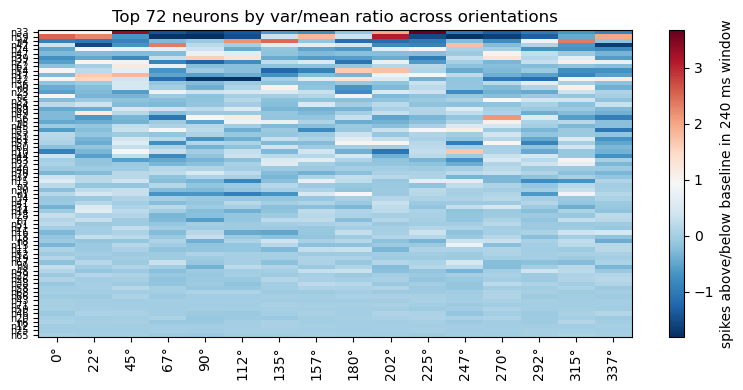

Top 72 neuron indices: [33 59  4 42 24 47 39 27 62 54 17 22 36  0 23  2 35 64 69 49 56  5 45 55
 53 61 57 60 10 44 63 32 40 70 37 15  3 30  1 34 41 31 14 28  7 51 21 16
 18  8 13 11 52 19 67  9 48 29 26 38 58 68 66 43 71 50 46 20  6 12 25 65]


In [261]:
TOP_K = 72

deviations = orient_total - orient_total.mean(axis=0)            # (16, n_neurons)
fanos = orient_total.var(axis=0) / orient_total.mean(axis=0)  # Fano factor per neuron across orientations
# top_neurons = np.argsort(orient_total.var(axis=0))[::-1][:TOP_K]
top_neurons = np.argsort(fanos)[::-1][:TOP_K]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(deviations[:, top_neurons].T, aspect='auto', cmap='RdBu_r')
ax.set_yticks(range(TOP_K))
ax.set_yticklabels([f'n{top_neurons[i]}' for i in range(TOP_K)], fontsize=7)
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}°' for d in visual_orientation_degs], rotation=90)
ax.set_title(f'Top {TOP_K} neurons by var/mean ratio across orientations')
plt.colorbar(im, ax=ax, label=f'spikes above/below baseline in {window} ms window')
plt.tight_layout()
plt.show()

print(f"Top {TOP_K} neuron indices: {top_neurons}")


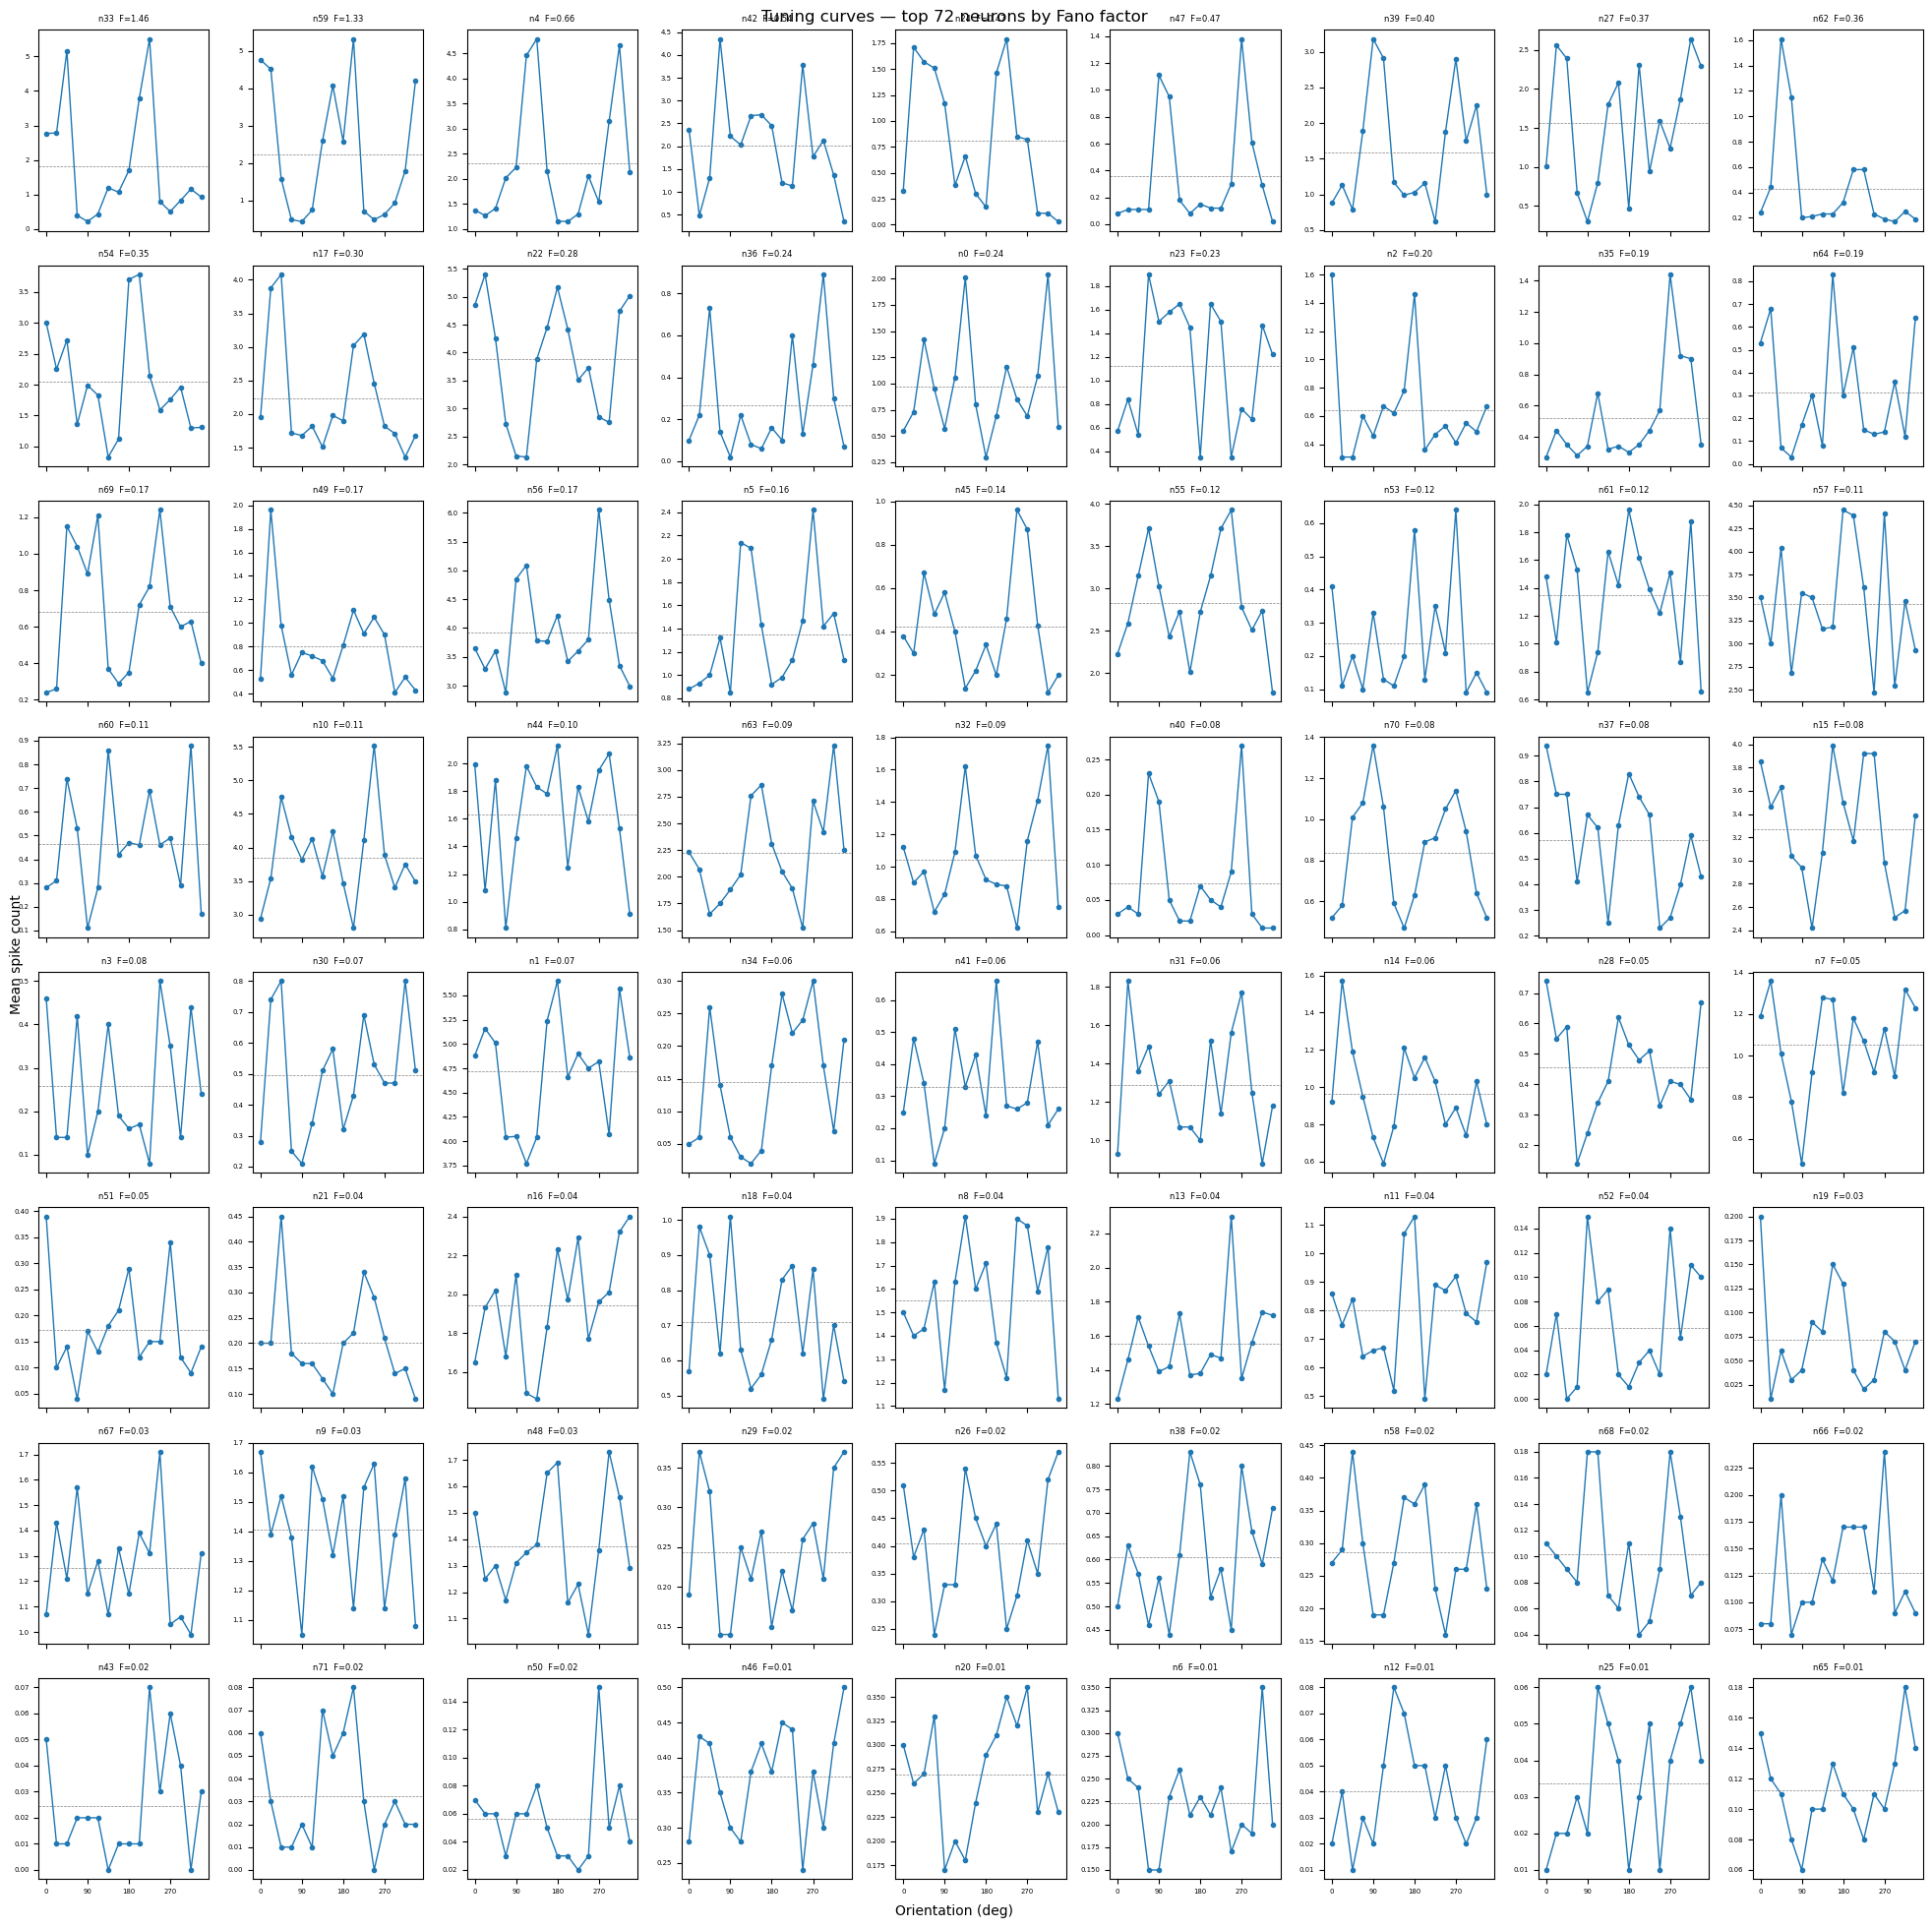

In [ ]:
# Tuning curves: mean spike count per orientation, per neuron
fig, axes = plt.subplots(8, 9, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for i, nidx in enumerate(top_neurons):
    ax = axes[i]
    ax.plot(visual_orientation_degs, orient_total[:, nidx], 'o-', ms=3, lw=1)
    ax.axhline(orient_total[:, nidx].mean(), color='gray', lw=0.5, linestyle='--')
    ax.set_title(f'n{nidx}', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_xticks(visual_orientation_degs[::4])

for ax in axes[len(top_neurons):]:
    ax.set_visible(False)

fig.supxlabel('Orientation (deg)', fontsize=10)
fig.supylabel('Mean spike count', fontsize=10)
fig.suptitle(f'Tuning curves — top {TOP_K} neurons by Fano factor', fontsize=12)
plt.tight_layout()
plt.show()


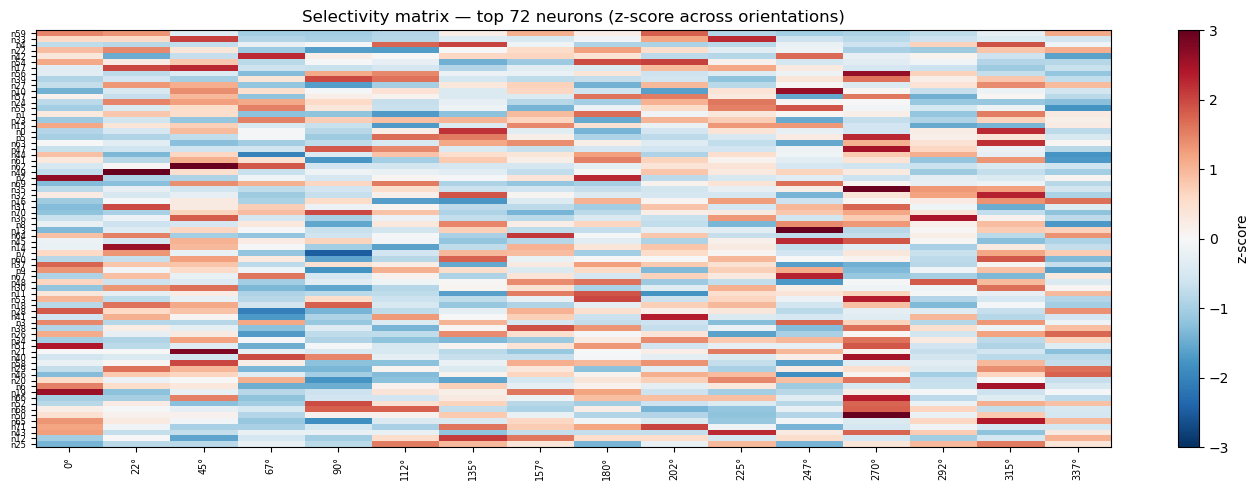

In [265]:
mu = orient_total.mean(axis=0)       # (n_neurons,)
sigma = orient_total.std(axis=0)     # (n_neurons,)

selectivity = (orient_total - mu) / (sigma + 1e-9)   # (n_orient, n_neurons)

top_neurons = np.argsort(sigma)[::-1][:TOP_K]         # rank by std (most modulated)

top_neuron_info = pd.DataFrame(
    selectivity[:, top_neurons],                       # (n_orient, TOP_K)
    index=[f'{int(d)}°' for d in visual_orientation_degs],
    columns=[f'n{i}' for i in top_neurons]
)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(top_neuron_info.values.T, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_xticklabels(top_neuron_info.index, rotation=90, fontsize=7)
ax.set_yticks(range(TOP_K))
ax.set_yticklabels(top_neuron_info.columns, fontsize=6)
ax.set_title(f'Selectivity matrix — top {TOP_K} neurons (z-score across orientations)')
plt.colorbar(im, ax=ax, label='z-score')
plt.tight_layout()
plt.show()


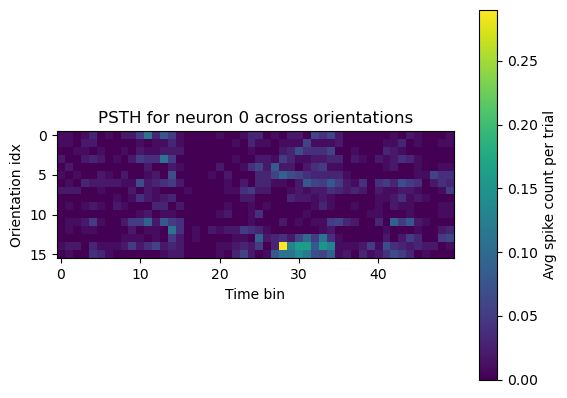

In [266]:
plt.imshow(sum_responses[:, 3, :])
plt.ylabel("Orientation idx")
plt.xlabel("Time bin")
plt.title("PSTH for neuron 0 across orientations")
plt.colorbar(label="Avg spike count per trial")
plt.show()

In [267]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Compute 3-axis projection: [CIS, PC1, PC2]
X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
mean_vec = X.mean(axis=0, keepdims=True)
pca3 = PCA(n_components=2)
pca3.fit(X)
proj, _ = np.linalg.qr(np.array([
    mean_vec[0],
    pca3.components_[0],
    pca3.components_[1],
]).T)                                       # (n_neurons, 3)

coords = X @ proj                           # (n_orientations, 3)  -- averaged points

# ---- Per-trial points: spike counts per (orientation, trial) summed over time bins ----
trial_coords = []     # (n_orient * n_trials, 3)
trial_doubled = []    # color matches its orientation
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial scatter (low alpha)
fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.05,
                line=dict(width=0)),
    name='Individual trials',
    hovertemplate='trial<extra></extra>',
    showlegend=True,
))

# Orientation-average scatter (full opacity, on top)
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='Orientation average',
))

fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)
fig.show()


In [268]:
# make a categorical vector of length (1, channels x amplitudes) 1-hot encoded). 
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
import os 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from utils import (read_pattern_json, preprocess_pattern_stimulations_df,
                   trial_breakout_spikes_and_patterns, BinnedStimSpikeDataset,
                   NUM_STIM_LEVELS)
from models import SimpleCausalSpikeCNN, train_epoch, validate

# --- Load pattern data (same pipeline as patterns_5k) ---
DATADIR = 'data'
pattern_df_raw = read_pattern_json(f'{DATADIR}/Combined_Pattern_Registrations.pkl')
pattern_df, _ = preprocess_pattern_stimulations_df(pattern_df_raw, align_to_stim=True)

# Use the same spikes_df already loaded above
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = np.sort(spikes_df['neuron_id'].unique())
spiking_neuron_to_index = {n: i for i, n in enumerate(spiking_neurons)}
n_neurons = len(spiking_neurons)
n_stim_channels = len(channel_to_index)
n_amplitudes = 2 # +- 3 uA
print(f"Stim channels: {n_stim_channels}, Neurons: {n_neurons}")


# --- Config (matching patterns_5k/config.yaml) ---
INPUT_BIN_MS   = 10
OUTPUT_BIN_MS  = 10
N_INPUT_BINS   = 80
N_OUTPUT_BINS  = 80
MAX_TIME_MS    = 720
OUTPUT_OFFSET  = 0
ENCODING_MODE  = 'current'
SEED = 42
np.random.seed(SEED)

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
    trial_breakout_spikes_and_patterns(
        spikes_df, pattern_df, channel_to_index,
        spiking_neurons=spiking_neurons,
        spiking_neuron_to_index=spiking_neuron_to_index,
        stim_time_ms=MAX_TIME_MS,
    )
)
print(f"Unique patterns: {len(pattern_stims)}, Total trials: {len(spike_responses)}")


# --- Train/val/test split: oracle patterns as test ---
unique_trials_info = pattern_df[['pattern_timing_index','pattern_name','is_oracle']].drop_duplicates()
oracle_timing    = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
non_oracle_timing = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
train_indices = non_oracle_timing
test_indices  = oracle_timing


Stim channels: 40, Neurons: 72
Unique patterns: 3100, Total trials: 4000


(36000, 160) (36000, 72) (12000, 160) (12000, 72)
(18000, 160) (18000, 72) (6000, 160) (6000, 72)
(9000, 160) (9000, 72) (3000, 160) (3000, 72)
(6000, 160) (6000, 72) (2000, 160) (2000, 72)
(3000, 160) (3000, 72) (1000, 160) (1000, 72)


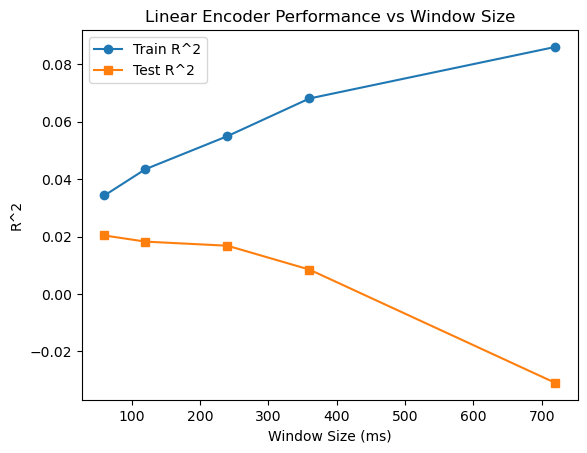

In [269]:

from utils import build_encoder_dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
train_r2s = []
test_r2s = []
for WINDOW_SIZE in [60, 120, 240, 360, 720]:
    MODE = "step"
    dataset = build_encoder_dataset(
        spike_responses, timing_to_pattern, pattern_stims, pattern_polarities, test_indices,
        n_stim_channels=n_stim_channels, n_amplitudes=n_amplitudes, n_neurons=n_neurons,
        WINDOW_SIZE=WINDOW_SIZE, SPIKE_LATENCY=0, MAX_TIME_MS=MAX_TIME_MS, MODE=MODE, OVERLAPS=False, oracle_mode='leftout'
    )

    train_X = dataset['train_X']
    train_Y = dataset['train_Y']
    test_X  = dataset['test_X']
    test_Y  = dataset['test_Y']
    print (train_X.shape, train_Y.shape, test_X.shape, test_Y.shape)


    reg = LinearRegression(fit_intercept=True).fit(train_X, train_Y)
    Y_pred = reg.predict(test_X)
    
    # 2. Calculate R^2 for each neuron
    # multioutput='raw_values' returns an array of R^2 scores, one per neuron
    train_r2_values = r2_score(train_Y, reg.predict(train_X), multioutput='raw_values')
    test_r2_values = r2_score(test_Y, Y_pred, multioutput='raw_values')
    train_r2s.append(np.mean(train_r2_values))
    test_r2s.append(np.mean(test_r2_values))
plt.title('Linear Encoder Performance vs Window Size')
plt.plot([60, 120, 240, 360, 720], train_r2s, marker='o', label='Train R^2')
plt.plot([60, 120, 240, 360, 720], test_r2s, marker='s', label='Test R^2')
plt.xlabel('Window Size (ms)')
plt.ylabel('R^2')
plt.legend()
plt.show()

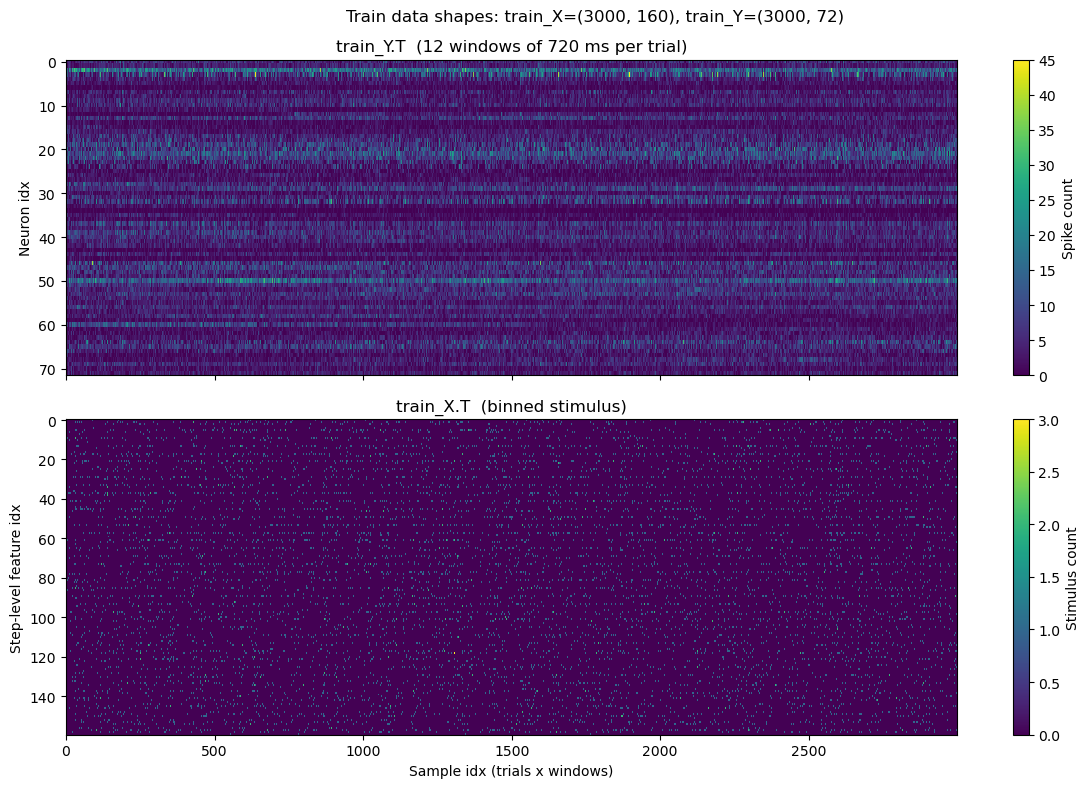

In [270]:
f, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
plt.suptitle(f"Train data shapes: train_X={train_X.shape}, train_Y={train_Y.shape}")
ax[0].imshow(train_Y.T, aspect='auto', interpolation='nearest')
ax[0].set_ylabel("Neuron idx")
ax[0].set_title(f"train_Y.T  ({MAX_TIME_MS//60} windows of {WINDOW_SIZE} ms per trial)")
ax[1].imshow(train_X.T, aspect='auto', interpolation='nearest')
ax[1].set_xlabel("Sample idx (trials x windows)")
ax[1].set_ylabel("Step-level feature idx" if MODE == "step" else "Pulse-level feature idx")
ax[1].set_title("train_X.T  (binned stimulus)")
plt.colorbar(ax[0].images[0], ax=ax[0], label='Spike count')
plt.colorbar(ax[1].images[0], ax=ax[1], label='Stimulus count')
plt.tight_layout()
plt.show()


In [271]:
# ============================================================
# Train SimpleCausalSpikeCNN on stim->spike prediction.
#   - inputs : per-electrode current ('current' encoding), 10 ms bins, +-3 amps
#   - targets: per-neuron spike counts, 10 ms bins
#   - train  : non-oracle trials (90/10 train/val split)
#   - test   : oracle trials
#   - stim channels only (no init state, no spike history)
#   - checkpoints + config + history saved to vis_stim/results/<run_name>/
# ============================================================
import os, sys, json, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
from utils  import BinnedStimSpikeDataset
from models import SimpleCausalSpikeCNN, train_epoch, validate

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else
                      'cpu')
print('device:', device)

# --- config ---
CFG = dict(
    INPUT_BIN_MS  = 10,
    OUTPUT_BIN_MS = 10,
    N_INPUT_BINS  = MAX_TIME_MS // 10,
    N_OUTPUT_BINS = MAX_TIME_MS // 10,
    MAX_TIME_MS   = MAX_TIME_MS,
    ENCODING_MODE = 'current',
    BATCH_SIZE    = 16,
    N_EPOCHS      = 50,
    LR            = 1e-3,
    WEIGHT_DECAY  = 0,
    VAL_FRAC      = 0.2,
    SEED          = 42,
    CONV_CHANNELS = [512, 256, 256],
    KERNEL_SIZES  = [20, 6, 3],
    FC_DIMS       = [512, 256],
    DROPOUT       = 0.2,
)

# --- output directory ---
os.makedirs('results', exist_ok=True)
run_name = time.strftime('%Y%m%d_%H%M%S') + '_simple_cnn'
run_dir  = os.path.join('results', run_name)
os.makedirs(run_dir, exist_ok=True)
print('run dir:', run_dir)

# --- datasets (non-oracle -> train+val, oracle -> test) ---
torch.manual_seed(CFG['SEED']); np.random.seed(CFG['SEED'])

train_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=train_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)
test_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=test_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)

# 90/10 train/val split of the non-oracle set.
n_total = len(train_ds)
perm = np.random.RandomState(CFG['SEED']).permutation(n_total)
n_val = max(1, int(n_total * CFG['VAL_FRAC']))
val_idx, tr_idx = perm[:n_val].tolist(), perm[n_val:].tolist()

# encoding_mode='current' returns int64 amplitudes (+-3); the model expects floats
# when the embedding layer is disabled. Cast in collate_fn.
def _float_collate(batch):
    xs = torch.stack([torch.as_tensor(b[0]).float() for b in batch])
    ys = torch.stack([torch.as_tensor(b[1]).float() for b in batch])
    return xs, ys

NUM_WORKERS = 0  # avoid macOS spawn pickling issues with cell-local collate fn
train_loader = DataLoader(Subset(train_ds, tr_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=True, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(Subset(train_ds, val_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
test_loader  = DataLoader(test_ds, batch_size=CFG['BATCH_SIZE'], shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
print(f'train: {len(tr_idx)}  val: {len(val_idx)}  test: {len(test_ds)}')

# --- model: stim-only, no embedding ---
model = SimpleCausalSpikeCNN(
    n_stim_channels=n_stim_channels,
    n_neurons=n_neurons,
    n_input_bins=CFG['N_INPUT_BINS'],
    n_output_bins=CFG['N_OUTPUT_BINS'],
    embedding_dim=1,                       # no embedding -> input passes through as-is
    conv_channels=CFG['CONV_CHANNELS'],
    kernel_sizes=CFG['KERNEL_SIZES'],
    fc_dims=CFG['FC_DIMS'],
    dropout=CFG['DROPOUT'],
    use_batch_norm=True,
    use_init_state=False,
).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'model params: {n_params:,}')

# --- training ---
# Build neuron weights from variance (all neurons, top ones get higher weight)
neuron_var = orient_total.var(axis=0)                          # (n_neurons,)
neuron_weights = np.sqrt(neuron_var) / np.sqrt(neuron_var).sum()   # soft normalization
neuron_weights_t = torch.tensor(neuron_weights, dtype=torch.float32).to(device)  # (n_neurons,)

base_criterion = nn.PoissonNLLLoss(log_input=True, full=True, reduction='none')

# def criterion(log_pred, target):
#     loss = base_criterion(log_pred, target)                    # (B, n_neurons, T)
#     loss = (loss * neuron_weights_t[None, :, None])            # weight by variance
#     return loss.sum()

optimizer = torch.optim.Adam(model.parameters(), lr=CFG['LR'], weight_decay=CFG['WEIGHT_DECAY'])

best_val = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_corr': []}
ckpt_best = os.path.join(run_dir, 'best.pth')
ckpt_last = os.path.join(run_dir, 'last.pth')

for epoch in range(1, CFG['N_EPOCHS'] + 1):
    train_loss = train_epoch(model, train_loader, base_criterion, optimizer, device,
                             grad_clip=True, max_norm=1.0)
    val_loss, val_corr = validate(model, val_loader, base_criterion, device)
    history['train_loss'].append(float(train_loss))
    history['val_loss'].append(float(val_loss))
    history['val_corr'].append(float(val_corr))
    print(f'epoch {epoch:>3}/{CFG["N_EPOCHS"]}  '
          f'train={train_loss:.4f}  val={val_loss:.4f}  val_corr={val_corr:.4f}')

    torch.save(model.state_dict(), ckpt_last)
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), ckpt_best)
        print(f'  [save] new best val={best_val:.4f}')

# --- final test on oracle trials (best ckpt) ---
model.load_state_dict(torch.load(ckpt_best, map_location=device))
test_loss, test_corr = validate(model, test_loader, base_criterion, device)
print(f'\noracle test loss: {test_loss:.4f}  test corr: {test_corr:.4f}')

# --- persist run metadata ---
CFG['n_stim_channels'] = int(n_stim_channels)
CFG['n_neurons']       = int(n_neurons)
CFG['n_train']         = len(tr_idx)
CFG['n_val']           = len(val_idx)
CFG['n_test']          = len(test_ds)
CFG['best_val_loss']   = float(best_val)
CFG['test_loss']       = float(test_loss)
CFG['test_corr']       = float(test_corr)
with open(os.path.join(run_dir, 'config.json'), 'w') as f:
    json.dump(CFG, f, indent=2)
with open(os.path.join(run_dir, 'history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print('saved config + history to', run_dir)



device: mps
run dir: results/20260506_092810_simple_cnn
0 trials were added in spike responses for initial state that were not in the specified trial_indices
0 trials were added in spike responses for initial state that were not in the specified trial_indices
train: 2400  val: 600  test: 1000
model params: 1,677,128


epoch   1/50  train=0.2622  val=0.2229  val_corr=0.1326
  [save] new best val=0.2229


epoch   2/50  train=0.2207  val=0.2138  val_corr=0.1826
  [save] new best val=0.2138


epoch   3/50  train=0.2127  val=0.2096  val_corr=0.2077
  [save] new best val=0.2096


epoch   4/50  train=0.2077  val=0.2046  val_corr=0.2310
  [save] new best val=0.2046


...

epoch  47/50  train=0.1644  val=0.1885  val_corr=0.3424


epoch  48/50  train=0.1641  val=0.1891  val_corr=0.3421


epoch  49/50  train=0.1640  val=0.1892  val_corr=0.3433


epoch  50/50  train=0.1636  val=0.1903  val_corr=0.3425



oracle test loss: 0.2281  test corr: 0.2390
saved config + history to results/20260506_092810_simple_cnn


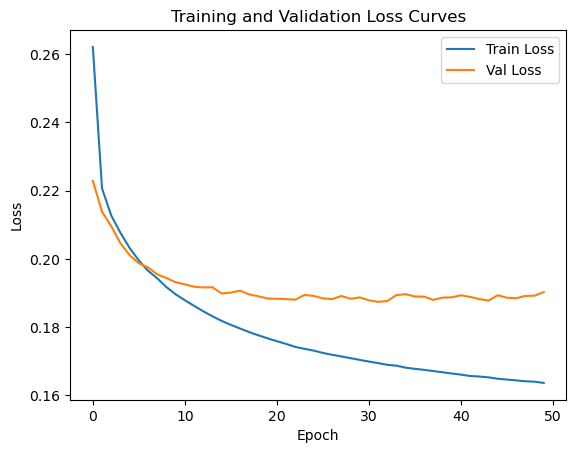

In [272]:


plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

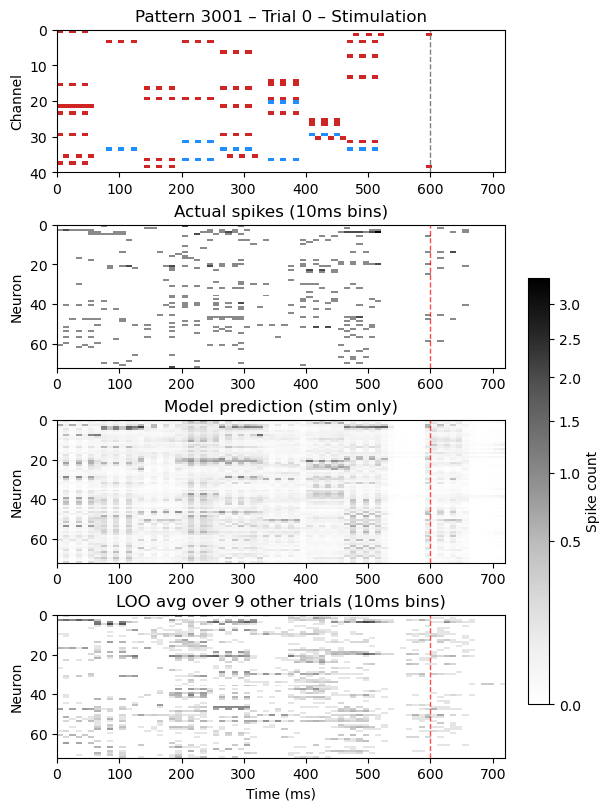

In [273]:
# ============================================================
# Visualize one trained CNN test example (oracle pattern), reusing
# patterns_5k/viz.py:plot_single_oracle_trial.
#
# Panels: stim polarity, actual spikes, model prediction, LOO trial average.
# ============================================================
import numpy as np
import torch
from viz import plot_single_oracle_trial

# Build the cfg + raw_data dicts the viz function expects.
cfg = dict(
    input_bin_size_ms  = CFG['INPUT_BIN_MS'],
    output_bin_size_ms = CFG['OUTPUT_BIN_MS'],
    n_input_bins       = CFG['N_INPUT_BINS'],
    n_output_bins      = CFG['N_OUTPUT_BINS'],
    max_time_ms        = CFG['MAX_TIME_MS'],
    output_offset      = 0,
    history            = 0,
    init_state         = False,
    encoding_mode      = CFG['ENCODING_MODE'],
)
raw_data = dict(
    pattern_df         = pattern_df,
    spike_responses    = spike_responses,
    pattern_polarities = pattern_polarities,
)
model_tuple = (model, criterion, device)

# Pick the first oracle pattern with at least 2 trials so LOO is meaningful.
unique_oracle = pattern_df[pattern_df['is_oracle']][['pattern_name', 'pattern_timing_index']].drop_duplicates()
counts = unique_oracle.groupby('pattern_name').size()
PATTERN_TO_SHOW = counts[counts >= 2].index[0] if (counts >= 2).any() else counts.index[0]
TRIAL_IDX = 0

fig = plot_single_oracle_trial(
    pattern_name=PATTERN_TO_SHOW,
    trial_idx=TRIAL_IDX,
    model_tuple=model_tuple,
    cfg=cfg,
    raw_data=raw_data,
    test_loader=test_loader,
    coarse_factor=1,
)

from IPython.display import display
fig.axes[2].set_title(f'Model prediction (stim only)')
display(fig)


### Compare NN vs Linear model for spike counts in target window 

train_X=(18000, 160)  train_Y=(18000, 72)  test_X=(6000, 160)  test_Y=(6000, 72)
(72,)
WINDOW_SIZE = 120 ms  (6 windows/trial)
Linear (reg):
  mean R^2 = 0.0182   median = 0.0113
  mean MSE = 1.5763
CNN (windowed):
  mean R^2 = 0.2458   median = 0.2166
  mean MSE = 1.0549


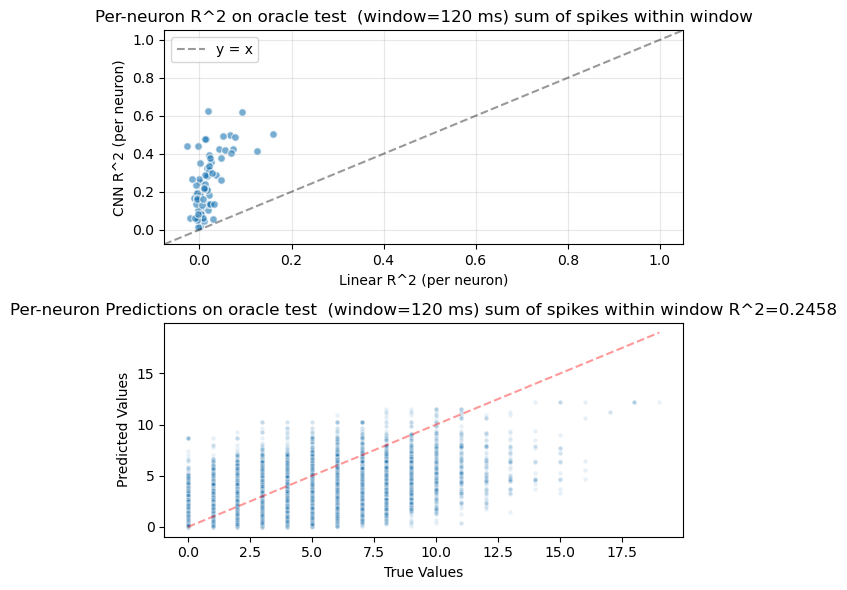

In [323]:
# ============================================================
# Compare windowed-spike-count R^2: linear model vs. trained CNN.
# Same paradigm as the linear sweep: train = non-oracle, test = oracle (leftout).
#
#   - Linear model (reg): operates directly at window resolution; R^2 on test_Y.
#   - CNN model: produces 10 ms-binned predictions per trial, then we SUM within
#     each window boundary used by build_encoder_dataset to get window-level
#     spike-count predictions on the same alignment as test_Y.
# ============================================================
import numpy as np
import torch
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from utils import build_encoder_dataset

WINDOW_SIZE = 120      # ms per window (must divide MAX_TIME_MS; for step mode also a multiple of 60)
assert MAX_TIME_MS % WINDOW_SIZE == 0, f'WINDOW_SIZE={WINDOW_SIZE} does not divide MAX_TIME_MS={MAX_TIME_MS}'
n_windows_per_trial = MAX_TIME_MS // WINDOW_SIZE
window_size_in_bins = WINDOW_SIZE // CFG['OUTPUT_BIN_MS']      # CNN output bins per window
assert WINDOW_SIZE % CFG['OUTPUT_BIN_MS'] == 0, 'WINDOW_SIZE must be a multiple of CNN output bin'

# --- 1. Build window-level dataset (linear-friendly) on the same paradigm. ---
ds = build_encoder_dataset(
    spike_responses, timing_to_pattern, pattern_stims, pattern_polarities, test_indices,
    n_stim_channels=n_stim_channels, n_amplitudes=n_amplitudes, n_neurons=n_neurons,
    WINDOW_SIZE=WINDOW_SIZE, SPIKE_LATENCY=0, MAX_TIME_MS=MAX_TIME_MS,
    MODE='step', OVERLAPS=False, oracle_mode='leftout',
)
train_X, train_Y = ds['train_X'], ds['train_Y']
test_X,  test_Y  = ds['test_X'],  ds['test_Y']
test_timings     = ds['test_timings']                      # one timing_idx per row of test_Y
print(f'train_X={train_X.shape}  train_Y={train_Y.shape}  test_X={test_X.shape}  test_Y={test_Y.shape}')

# --- 2. Linear model: train on non-oracle, predict on oracle. ---
reg = LinearRegression(fit_intercept=True).fit(train_X, train_Y)
Y_pred_lr = reg.predict(test_X)

# --- 3. CNN model: predict at 10ms resolution, sum within each window. ---
unique_trial_idxs = []
seen = set()
for ti in test_timings:
    if int(ti) not in seen:
        unique_trial_idxs.append(int(ti))
        seen.add(int(ti))

# Pull stim per trial from test_ds (CNN-side dataset built in cell 13).
stim_by_timing = {ti: test_ds.pattern_stims[test_ds.timing_to_pattern[ti]]
                  for ti in unique_trial_idxs}

model.eval()
trial_window_preds = {}
with torch.no_grad():
    for ti in unique_trial_idxs:
        x = torch.as_tensor(stim_by_timing[ti]).float().unsqueeze(0).to(device)
        log_pred = model(x).squeeze(0).cpu().numpy()                  # (n_neurons, n_output_bins)
        rate = np.exp(log_pred)
        rate = rate[:, :n_windows_per_trial * window_size_in_bins]
        windowed = rate.reshape(n_neurons, n_windows_per_trial, window_size_in_bins).sum(axis=-1)
        trial_window_preds[ti] = windowed.T                            # (n_windows, n_neurons)

# Re-emit predictions in the same row order as test_Y / test_timings.
Y_pred_nn = np.zeros_like(test_Y)
for row_idx, ti in enumerate(test_timings):
    win_within_trial = row_idx % n_windows_per_trial
    Y_pred_nn[row_idx] = trial_window_preds[int(ti)][win_within_trial]

# --- 4. Per-neuron R^2 / MSE for both models. ---
r2_lr  = r2_score(test_Y, Y_pred_lr, multioutput='raw_values')
print (r2_lr.shape)
mse_lr = mean_squared_error(test_Y, Y_pred_lr, multioutput='raw_values')
r2_nn  = r2_score(test_Y, Y_pred_nn, multioutput='raw_values')
mse_nn = mean_squared_error(test_Y, Y_pred_nn, multioutput='raw_values')

print(f'WINDOW_SIZE = {WINDOW_SIZE} ms  ({n_windows_per_trial} windows/trial)')
print('Linear (reg):')
print(f'  mean R^2 = {np.mean(r2_lr):.4f}   median = {np.median(r2_lr):.4f}')
print(f'  mean MSE = {np.mean(mse_lr):.4f}')
print('CNN (windowed):')
print(f'  mean R^2 = {np.mean(r2_nn):.4f}   median = {np.median(r2_nn):.4f}')
print(f'  mean MSE = {np.mean(mse_nn):.4f}')

# Per-neuron R^2 scatter (linear vs CNN).
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(6, 6))
ax[0].scatter(r2_lr, r2_nn, alpha=0.6, s=30, edgecolor='w')
lo = min(r2_lr.min(), r2_nn.min(), 0) - 0.05
hi = max(r2_lr.max(), r2_nn.max(), 1) + 0.05
ax[0].plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y = x') # TODO fix aspect ratio
ax[0].set_xlabel('Linear R^2 (per neuron)')
ax[0].set_ylabel('CNN R^2 (per neuron)')
ax[0].set_title(f'Per-neuron R^2 on oracle test  (window={WINDOW_SIZE} ms) sum of spikes within window')
ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].scatter(test_Y.flatten(), Y_pred_nn.flatten(), alpha=0.1, s=10, edgecolor='w')
ax[1].set_xlabel('True Values')
ax[1].set_ylabel('Predicted Values')
ax[1].plot([0, test_Y.flatten().max()], [0, test_Y.flatten().max()], 'r--', alpha=0.4) # identity line
ax[1].set_title(f'Per-neuron Predictions on oracle test  (window={WINDOW_SIZE} ms) sum of spikes within window R^2={np.mean(r2_nn):.4f}')

plt.tight_layout()
plt.show()


per-neuron-mean correlation: r = 0.9839  (p = 3.96e-54)


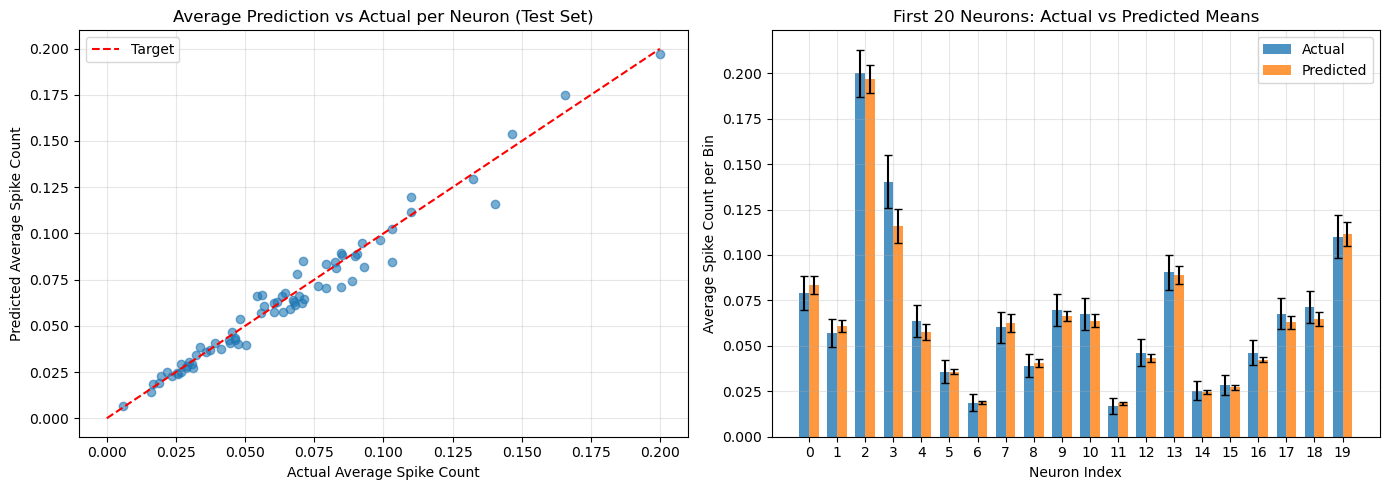

In [324]:
# ============================================================
# Per-neuron correlation between predicted and observed responses on the
# oracle test set. Reuses patterns_5k/viz.py:plot_test_prediction_comparison.
# ============================================================
import numpy as np
import torch
from viz import plot_test_prediction_comparison

# Run model over the oracle test set, collect log predictions and targets.
model.eval()
all_log_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        all_log_preds.append(model(xb).cpu().numpy())   # (B, n_neurons, T)
        all_targets.append(yb.numpy())
all_log_preds = np.concatenate(all_log_preds, axis=0)   # (N, n_neurons, T)
all_targets   = np.concatenate(all_targets,   axis=0)

fig, axes, corr, pval = plot_test_prediction_comparison(
    all_log_preds, all_targets,
    savepath=os.path.join(run_dir, 'test_prediction_comparison.png'),
)
print(f'per-neuron-mean correlation: r = {corr:.4f}  (p = {pval:.2e})')


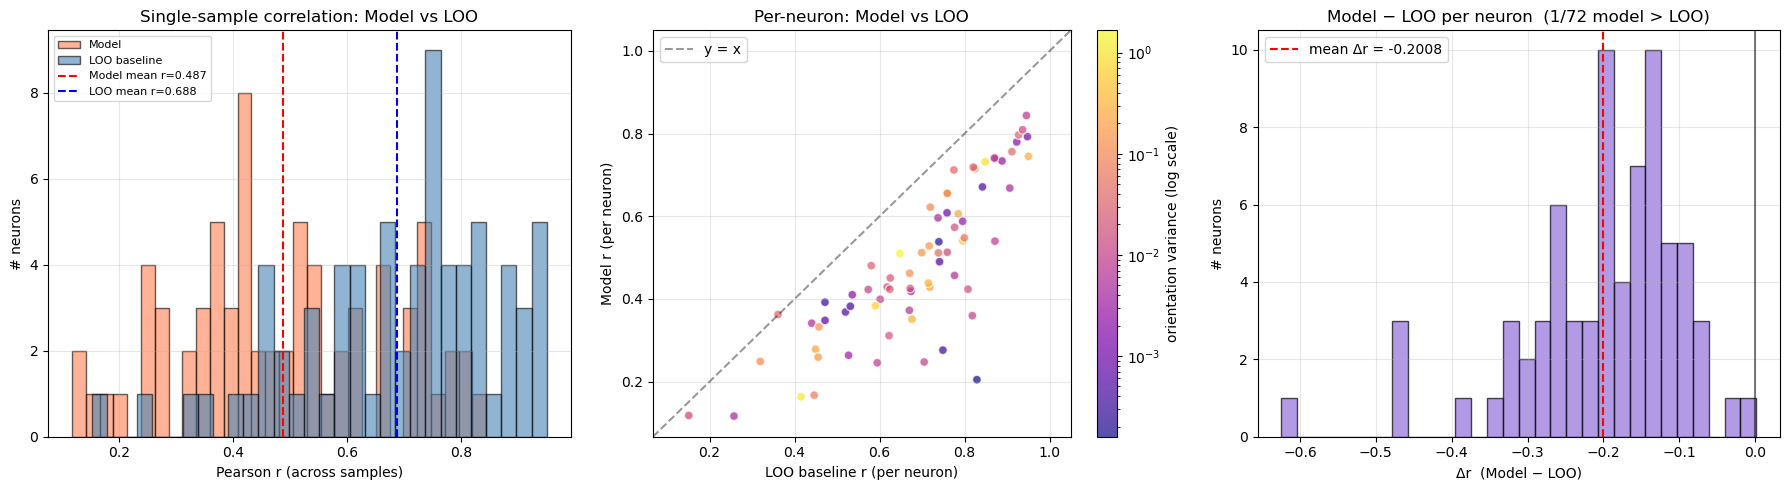

Model: mean r = 0.4869  median = 0.4594
LOO:   mean r = 0.6877  median = 0.7188
Neurons where model > LOO: 1 / 72
Mean Δr (model − LOO):     -0.2008


In [325]:
# ============================================================
# Model vs. LOO baseline correlation on the oracle test set.
# Mirrors the analysis from patterns_5k/5k_dataset_icms150_simple.ipynb
# (single-sample per-neuron Pearson r). LOO is the per-bin average of
# every other trial of the same pattern -- a noise-ceiling baseline.
# TODO: factor this into patterns_5k/viz.py so it isn't duplicated.
# ============================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import pearsonr

# Group test trial indices by pattern_name (oracle patterns -> >=2 trials each).
baseline_pattern_to_timing = defaultdict(list)
for timing_idx in test_ds.trial_indices:
    baseline_pattern_to_timing[test_ds.timing_to_pattern[timing_idx]].append(timing_idx)

n_samples = len(test_ds)
sample_true_rates  = np.zeros((n_samples, n_neurons))
sample_loo_rates   = np.zeros((n_samples, n_neurons))
sample_model_rates = np.zeros((n_samples, n_neurons))

# Model predictions at the per-sample level (mean over output bins).
model.eval()
loader = torch.utils.data.DataLoader(test_ds, batch_size=256, shuffle=False,
                                     collate_fn=_float_collate, num_workers=0)
idx = 0
with torch.no_grad():
    for bx, _ in loader:
        bx = bx.to(device)
        rate = torch.exp(model(bx)).cpu().numpy()        # (B, n_neurons, T)
        bs = rate.shape[0]
        sample_model_rates[idx:idx + bs] = rate.mean(axis=2)
        idx += bs

# Per-sample actual rates and LOO predictions (same window the model sees).
for i in range(n_samples):
    timing_idx, t = test_ds.samples[i]
    pname = test_ds.timing_to_pattern[timing_idx]
    spikes_full = test_ds.spike_responses_binned[timing_idx]
    out_start = t + test_ds.output_offset
    y = spikes_full[:, out_start:out_start + test_ds.n_output_bins]
    sample_true_rates[i] = y.mean(axis=1)

    others = [ti for ti in baseline_pattern_to_timing[pname] if ti != timing_idx]
    if not others:
        sample_loo_rates[i] = 0.0
        continue
    acc = np.zeros_like(y, dtype=np.float64)
    for oti in others:
        acc += test_ds.spike_responses_binned[oti][:, out_start:out_start + test_ds.n_output_bins]
    sample_loo_rates[i] = (acc / len(others)).mean(axis=1)

# Per-neuron Pearson r across samples.
def _per_neuron_r(P, T):
    rs = np.zeros(P.shape[1])
    for n in range(P.shape[1]):
        if P[:, n].std() > 0 and T[:, n].std() > 0:
            rs[n] = pearsonr(T[:, n], P[:, n])[0]
    return rs
r_loo   = _per_neuron_r(sample_loo_rates,   sample_true_rates)
r_model = _per_neuron_r(sample_model_rates, sample_true_rates)
diff = r_model - r_loo

# Plot: histograms / scatter / improvement-Δr.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(r_model, bins=30, alpha=0.6, color='coral', edgecolor='k', label='Model')
axes[0].hist(r_loo,   bins=30, alpha=0.6, color='steelblue', edgecolor='k', label='LOO baseline')
axes[0].axvline(np.mean(r_model), color='red',  linestyle='--', label=f'Model mean r={np.mean(r_model):.3f}')
axes[0].axvline(np.mean(r_loo),   color='blue', linestyle='--', label=f'LOO mean r={np.mean(r_loo):.3f}')
axes[0].set_xlabel('Pearson r (across samples)')
axes[0].set_ylabel('# neurons')
axes[0].set_title('Single-sample correlation: Model vs LOO')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

neuron_var = orient_total.var(axis=0)   # (n_neurons,) — reuse or move above if already computed

sc = axes[1].scatter(r_loo, r_model, alpha=0.7, s=40, edgecolor='w',
                     c=neuron_var, cmap='plasma', norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(sc, ax=axes[1], label='orientation variance (log scale)')
lim = [min(r_loo.min(), r_model.min()) - 0.05, 1.05]
axes[1].plot(lim, lim, 'k--', alpha=0.4, label='y = x')
axes[1].set_xlabel('LOO baseline r (per neuron)')
axes[1].set_ylabel('Model r (per neuron)')
axes[1].set_title('Per-neuron: Model vs LOO')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].legend(); axes[1].grid(alpha=0.3)


axes[2].hist(diff, bins=30, alpha=0.7, color='mediumpurple', edgecolor='k')
axes[2].axvline(0, color='k', alpha=0.5)
axes[2].axvline(np.mean(diff), color='red', linestyle='--', label=f'mean Δr = {np.mean(diff):.4f}')
axes[2].set_xlabel('Δr  (Model − LOO)')
axes[2].set_ylabel('# neurons')
axes[2].set_title(f'Model − LOO per neuron  ({(diff > 0).sum()}/{len(diff)} model > LOO)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(run_dir, 'model_vs_loo_correlation.png'), dpi=150)
plt.show()

print(f'Model: mean r = {np.mean(r_model):.4f}  median = {np.median(r_model):.4f}')
print(f'LOO:   mean r = {np.mean(r_loo):.4f}  median = {np.median(r_loo):.4f}')
print(f'Neurons where model > LOO: {(diff > 0).sum()} / {len(diff)}')
print(f'Mean Δr (model − LOO):     {np.mean(diff):.4f}')


In [277]:
print(f"neuron_var range: {neuron_var.min():.4f} – {neuron_var.max():.4f}")
print(f"neuron_var percentiles: {np.percentile(neuron_var, [1, 25, 50, 75, 99]).round(4)}")


neuron_var range: 0.0003 – 2.9662
neuron_var percentiles: [3.0000e-04 8.8000e-03 5.7900e-02 2.2440e-01 2.7563e+00]


In [303]:
from utils import build_pattern_stims_nominal

WINDOW_SIZE_MS = 120
assert WINDOW_SIZE_MS % CFG['INPUT_BIN_MS'] == 0
assert MAX_TIME_MS % WINDOW_SIZE_MS == 0
bins_per_window = WINDOW_SIZE_MS // CFG['INPUT_BIN_MS']
n_windows_trial = MAX_TIME_MS // WINDOW_SIZE_MS

# Use nominal-aligned 10ms-binned stims so every 60ms step has clean pulse offsets.
pattern_stims_nominal = build_pattern_stims_nominal(pattern_df, channel_to_index, MAX_TIME_MS)

VALID_OFFSETS = {(0, 2, 4), (1, 3, 5), (0, 1, 2, 3, 4, 5)}
def is_valid_step_window(sl):
    n_steps = sl.shape[1] // 6
    for step in range(n_steps):
        sub = sl[:, step * 6:(step + 1) * 6]
        for ch in range(sub.shape[0]):
            nonzero = tuple(np.flatnonzero(sub[ch]).tolist())
            if len(nonzero) == 0:
                continue
            if nonzero not in VALID_OFFSETS:
                return False
            amps = sub[ch, list(nonzero)]
            if not np.all(amps == amps[0]) or amps[0] not in (-3, 3):
                return False
    return True

seen = {}
unique_windows = []
n_skipped = 0
for pname in pattern_stims_nominal:
    arr = pattern_stims_nominal[pname]
    for w in range(n_windows_trial):
        sl = arr[:, w * bins_per_window:(w + 1) * bins_per_window]
        if not is_valid_step_window(sl):
            n_skipped += 1
            continue
        key = sl.tobytes()
        if key not in seen:
            seen[key] = 0
            unique_windows.append(sl)
        seen[key] += 1

unique_windows = np.stack(unique_windows, axis=0)
pattern_counts = np.array([seen[w.tobytes()] for w in unique_windows])
MIN_COUNT = 1
mask = pattern_counts >= MIN_COUNT
unique_windows = unique_windows[mask]
pattern_counts = pattern_counts[mask]
print(f"unique {WINDOW_SIZE_MS}-ms stim windows: {unique_windows.shape[0]} (skipped {n_skipped} partial)")


# 2) Build full-trial CNN inputs: zero-pad each window into the full
#    n_input_bins length so the trained CNN can consume it. Place the
#    window at t=0; we'll read predictions over those same bi|ns.
N_INPUT_BINS = CFG['N_INPUT_BINS']
input_offset_bins = 1
full_inputs = np.zeros((unique_windows.shape[0], n_stim_channels, N_INPUT_BINS),
                       dtype=np.float32)
full_inputs[:, :, input_offset_bins:input_offset_bins + bins_per_window] = unique_windows # take first bins_per_window bins of the full input as the window; rest are zero-padded
full_inputs_t = torch.from_numpy(full_inputs).to(device)


# 3) Per-orientation observed total-spike target over a WINDOW_SIZE window.
#    sum_responses is (n_orient, n_neurons, N_BINS) at BIN_MS resolution.


unique 120-ms stim windows: 15343 (skipped 0 partial)


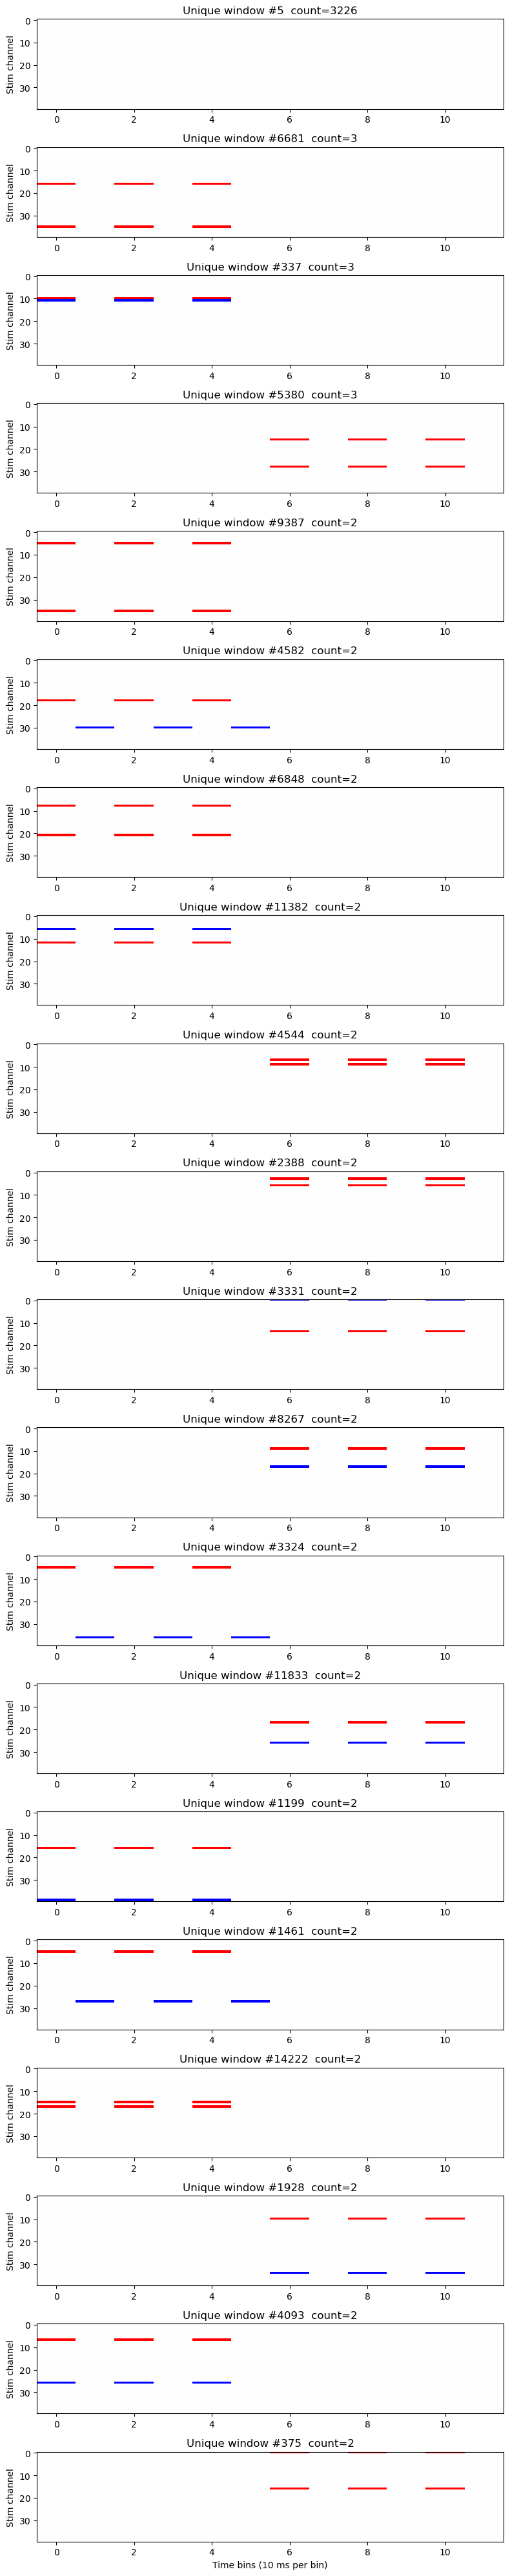

In [304]:
# Plot all of the unique windows, sorted by how many times they appear in the dataset.
import matplotlib.pyplot as plt
sorted_indices = np.argsort(pattern_counts)[::-1]
n_show = min(20, len(unique_windows))
fig, axes = plt.subplots(n_show, 1, figsize=(8, n_show * 2))
for i in range(n_show):
    idx = sorted_indices[i]
    axes[i].imshow(unique_windows[idx], aspect='auto', cmap='bwr', vmin=-3, vmax=3)
    axes[i].set_title(f'Unique window #{idx}  count={pattern_counts[idx]}')
    axes[i].set_ylabel('Stim channel')
axes[-1].set_xlabel(f'Time bins ({CFG["INPUT_BIN_MS"]} ms per bin)')
plt.tight_layout()
plt.show()

## Greedy pattern search over WINDOW SIZE MS for pattern most likely to give target spike count 

12  bins per window


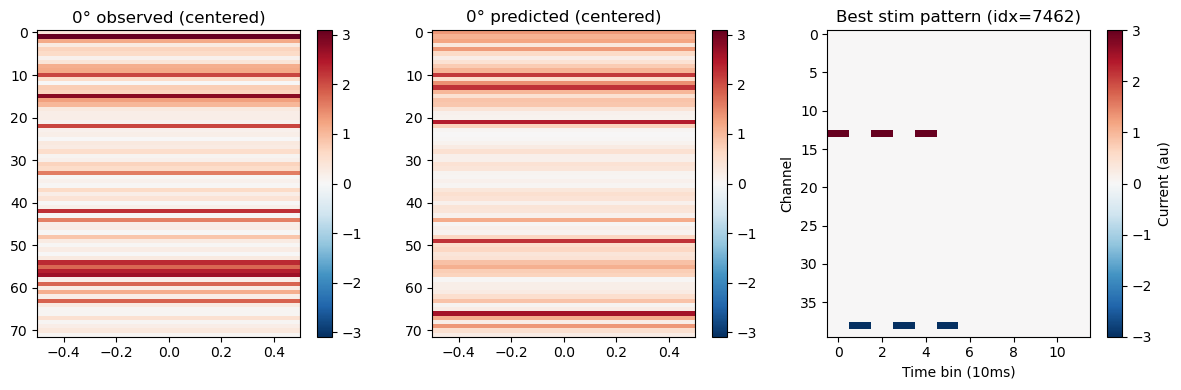

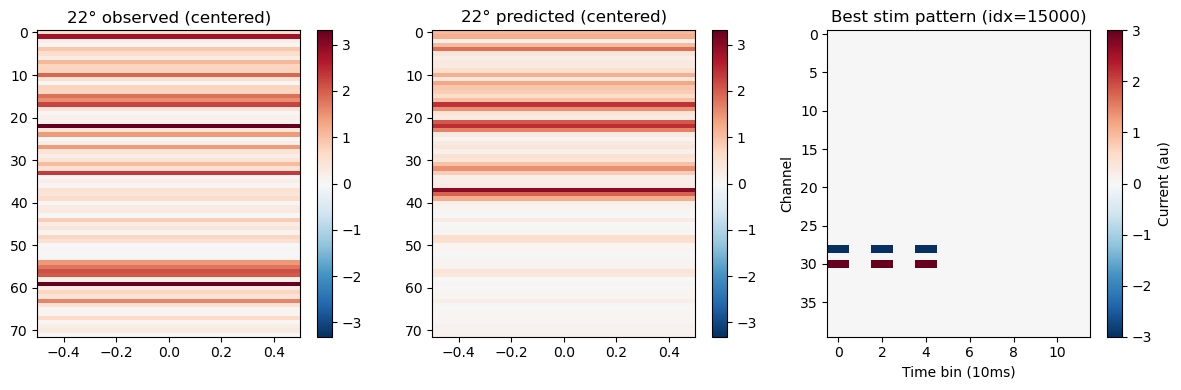

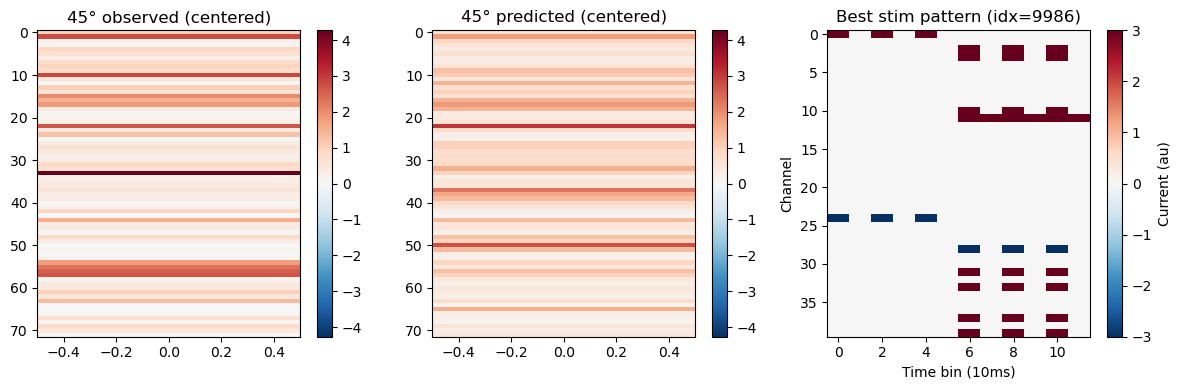

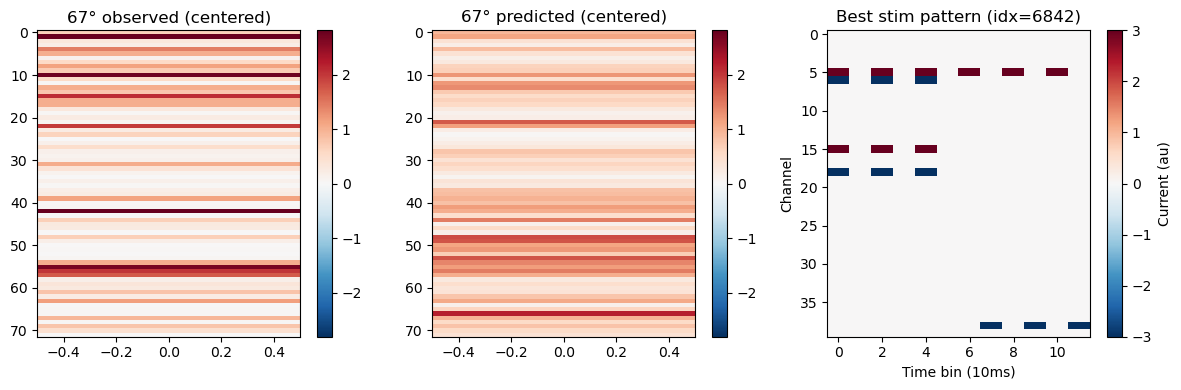

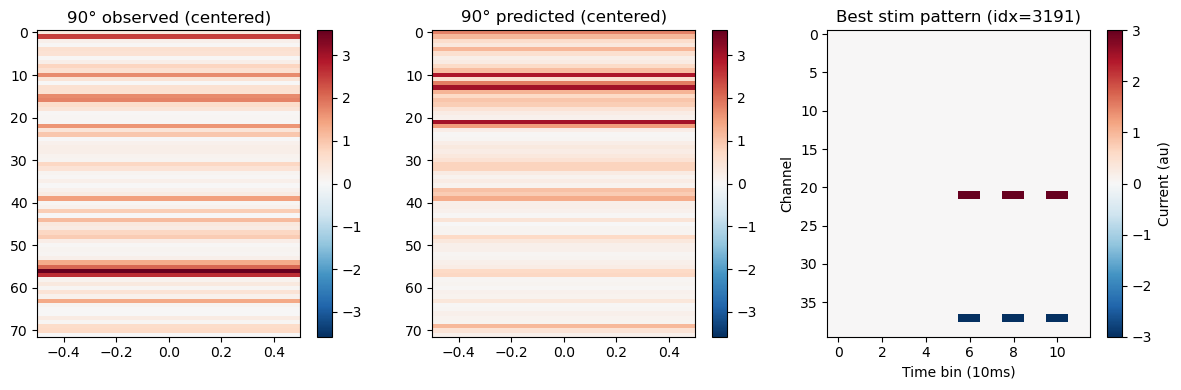

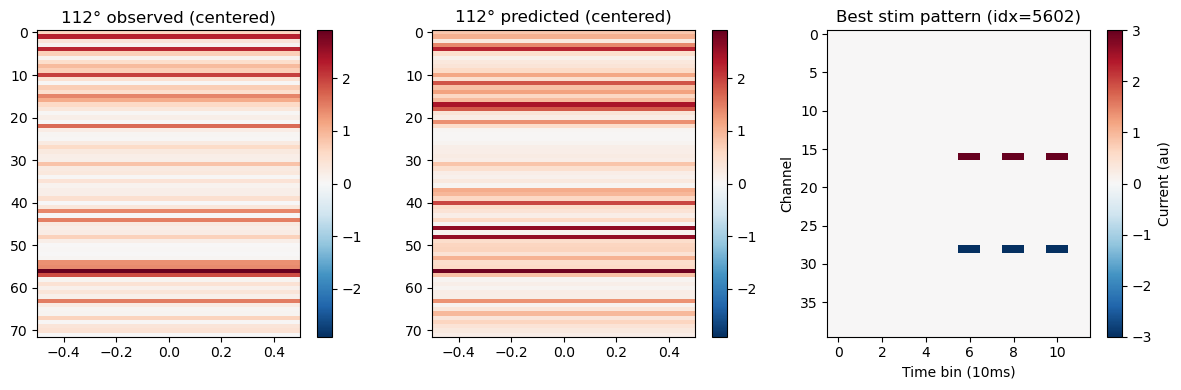

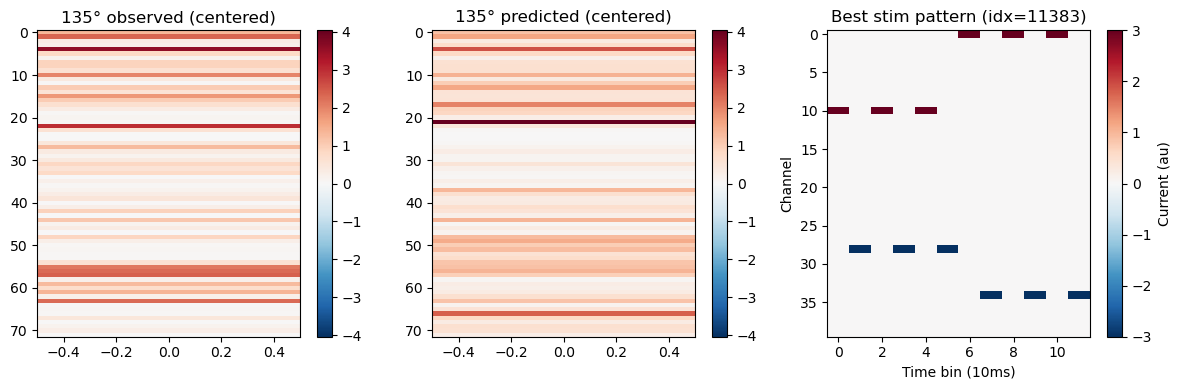

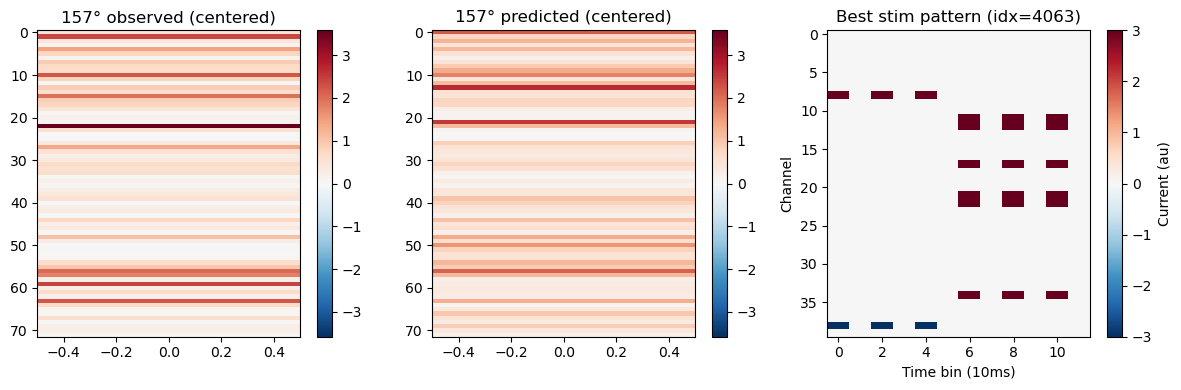

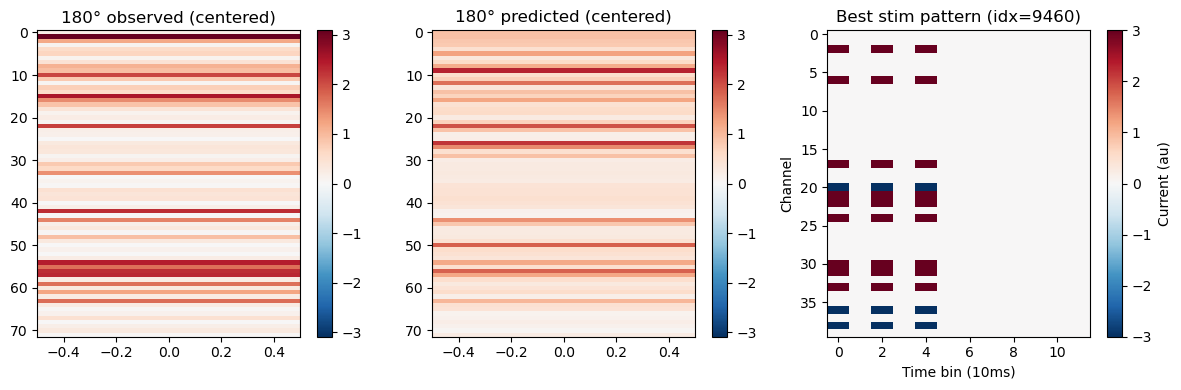

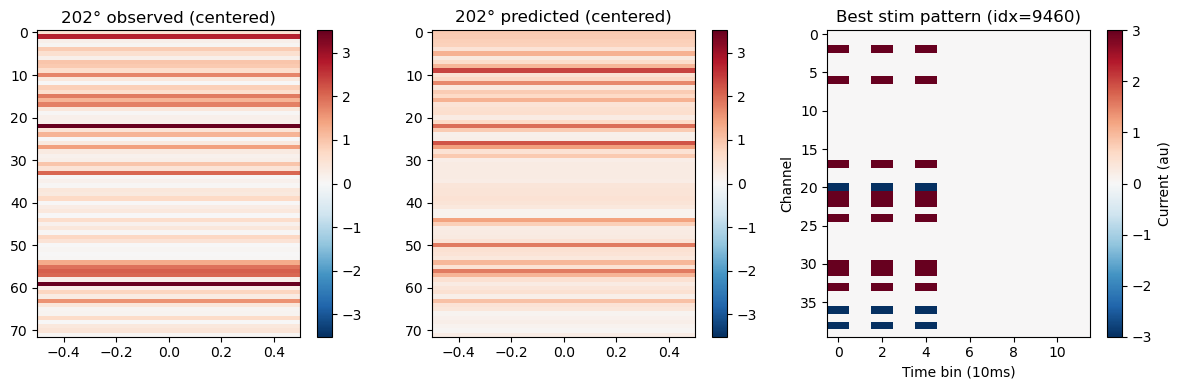

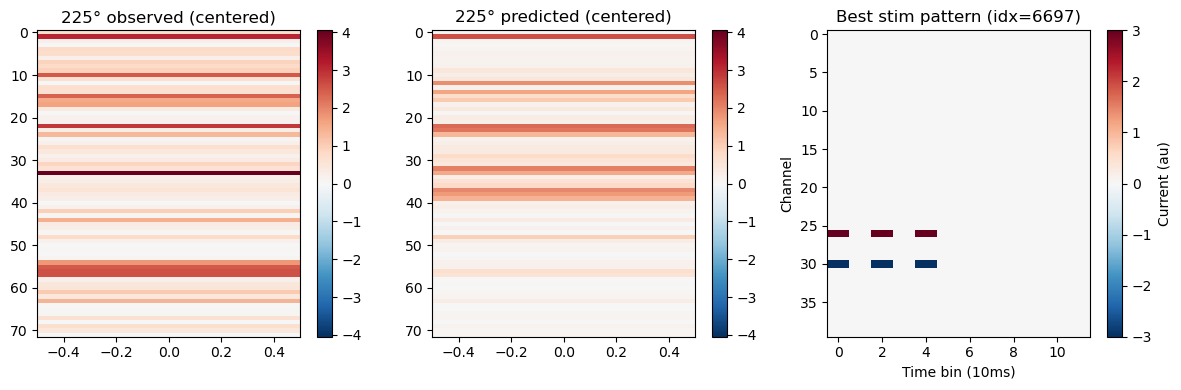

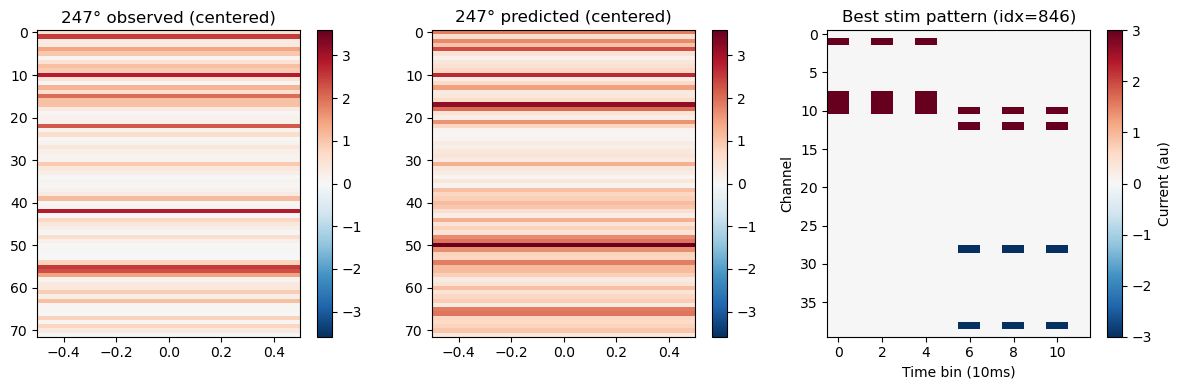

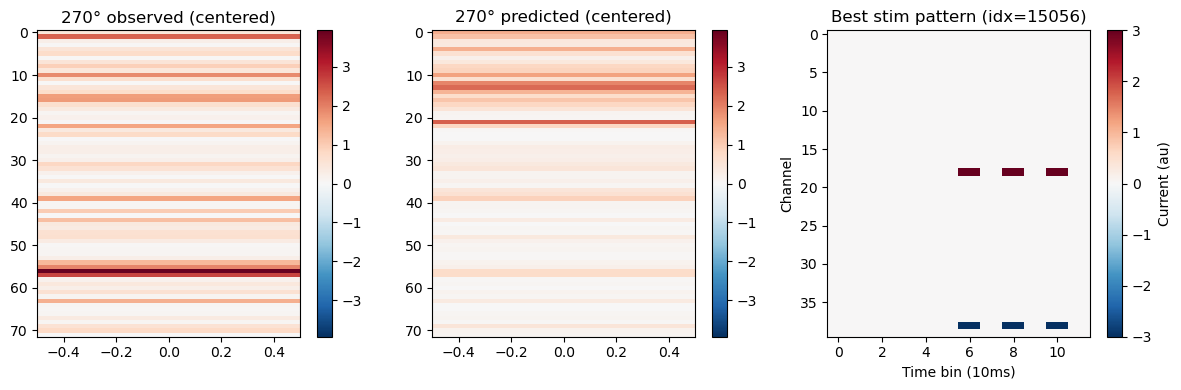

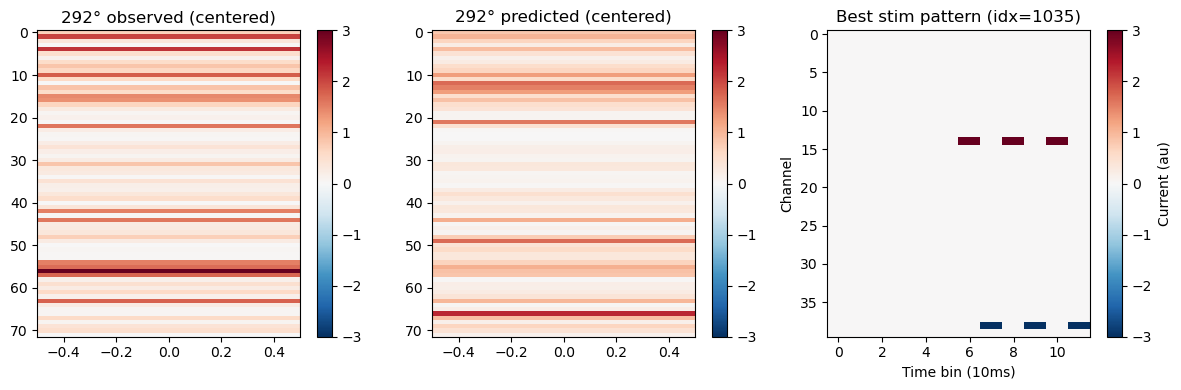

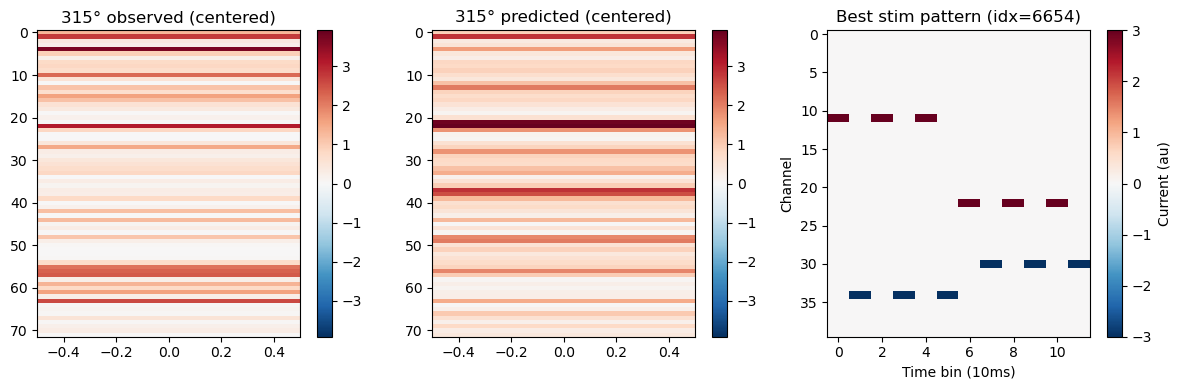

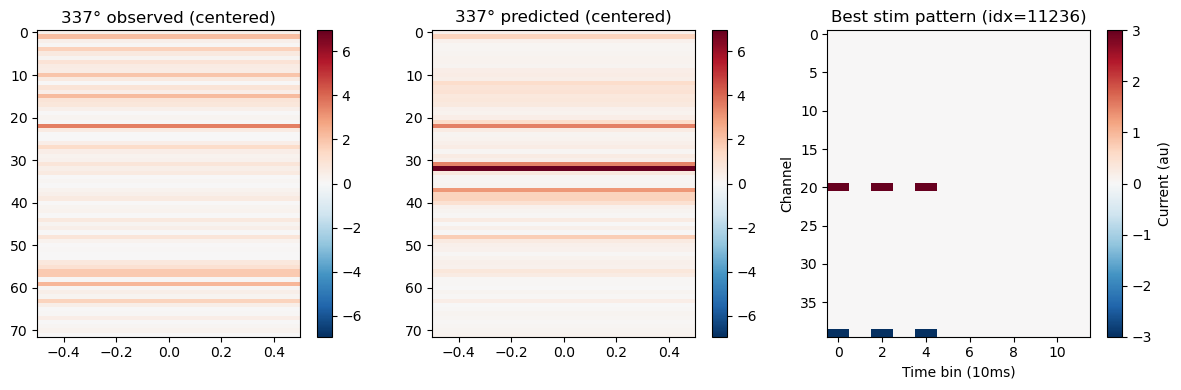


unique best patterns: 15 / 16


In [342]:
# 4) Run the trained CNN; truncate prediction to the window, sum over those
#    bins -> per-neuron predicted spike count per pattern.
model.eval()
pred_total = np.zeros((unique_windows.shape[0], n_neurons), dtype=np.float32)
with torch.no_grad():
    BS = 256
    for i in range(0, full_inputs_t.shape[0], BS):
        log_rate = model(full_inputs_t[i:i + BS])             # (B, n_neurons, n_out_bins)
        rate = torch.exp(log_rate)                            # PoissonNLL log_input=True
        # truncate to the WINDOW_SIZE_MS bins, sum over time -> (B, n_neurons)

        # sample here? or just take the mean prediction? taking the mean is more stable and deterministic, but sampling would be more faithful to the model's generative nature. could do both and compare.
        pred_total[i:i + BS] = rate[:, :, :bins_per_window].sum(dim=2).cpu().numpy() # sum over the window bins to get total predicted spikes per neuron for that window

# Per-orientation per-neuron target over the matching WINDOW_SIZE_MS window.
print (bins_per_window, " bins per window")

# Per-orientation per-neuron target over the matching WINDOW_SIZE_MS window.
orient_total = sum_responses[:, :, :bins_per_window].sum(axis=2)   # (n_orient, n_neurons)
orient_mean = orient_total.mean(axis=0)   # (n_neurons,) shared baseline
pred_mean   = pred_total.mean(axis=0)

# orient_c = orient_total - orient_mean     # (n_orient, n_neurons)
# pred_c   = pred_total   - pred_mean       # (P, n_neurons)
orient_c = orient_total
pred_c   = pred_total

# Use absolute selectivity as weights (both + and - tuned neurons matter)
sel_weights = np.exp(selectivity)                                         # (n_orient, n_neurons)
sel_weights = sel_weights / (sel_weights.sum(axis=1, keepdims=True) + 1e-9)

# sel_weights = np.ones((n_orient, n_neurons)) / n_neurons

dists = np.zeros((len(visual_orientation_degs), unique_windows.shape[0]), dtype=np.float32)
for o in range(len(visual_orientation_degs)):
    dists[o] = np.abs(orient_c[o] - pred_c) @ sel_weights[o]


best_idx = dists.argmin(axis=1)
best_dists = dists[np.arange(len(best_idx)), best_idx]

for o, deg in enumerate(visual_orientation_degs):
    f, ax = plt.subplots(1, 3, figsize=(12, 4))
    vmax = max(np.abs(orient_c[o]).max(), np.abs(pred_c[best_idx[o]]).max())

    ax[0].imshow(orient_c[o].reshape(-1, 1), aspect='auto', interpolation='nearest',
                 cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax[0].set_title(f'{int(deg)}° observed (centered)')
    plt.colorbar(ax[0].images[0], ax=ax[0])

    ax[1].imshow(pred_c[best_idx[o]].reshape(-1, 1), aspect='auto', interpolation='nearest',
                 cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax[1].set_title(f'{int(deg)}° predicted (centered)')
    plt.colorbar(ax[1].images[0], ax=ax[1])

    stim_pattern = unique_windows[best_idx[o]]   # (n_stim_channels, bins_per_window)
    amp_max = max(np.abs(stim_pattern).max(), 1)
    ax[2].imshow(stim_pattern, aspect='auto', interpolation='nearest',
                 cmap='RdBu_r', vmin=-amp_max, vmax=amp_max)
    ax[2].set_title(f'Best stim pattern (idx={best_idx[o]})')
    ax[2].set_xlabel('Time bin (10ms)')
    ax[2].set_ylabel('Channel')
    plt.colorbar(ax[2].images[0], ax=ax[2], label='Current (au)')

    plt.tight_layout()
    plt.show()
print(f"\nunique best patterns: {len(set(best_idx.tolist()))} / {len(visual_orientation_degs)}")


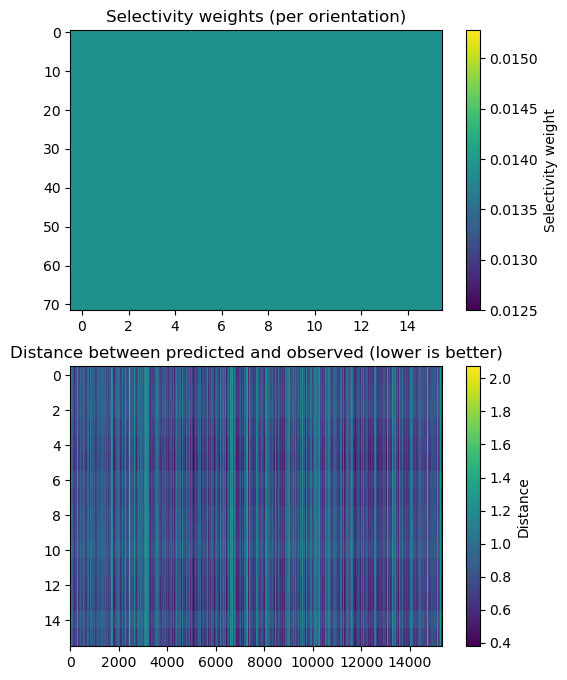

In [341]:
f, ax = plt.subplots(2, 1, figsize=(6, 8))
im1 = ax[0].imshow(sel_weights.T, aspect='auto', interpolation='nearest')
ax[0].set_title('Selectivity weights (per orientation)')
im2 = ax[1].imshow(dists, aspect='auto', interpolation='nearest')
ax[1].set_title('Distance between predicted and observed (lower is better)')
plt.colorbar(im1, label='Selectivity weight', ax=ax[0])
plt.colorbar(im2, label='Distance', ax=ax[1])

In [317]:
# Overlay the CNN-predicted responses for each orientation's best-match pattern
# onto the same [CIS, PC1, PC2] axes used for sum_responses earlier.
import plotly.graph_objects as go

# Reuse `proj` from the orientation plot (CIS + PC1/PC2 of orientation means).
# coords: orientation averages.  pred_coords: best-match CNN predictions.
coords       = X @ proj                                  # (n_orient, 3) -- recomputed for clarity
pred_coords  = pred_total[best_idx] @ proj               # (n_orient, 3)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Orientation averages (observed visual responses).
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                line=dict(color='black', width=1),
                colorbar=dict(title='Orientation (°)',
                              tickvals=np.arange(0, 361, 72),
                              ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)])),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='Observed orientation avg',
))

# Best-match CNN predictions (one per orientation).
fig.add_trace(go.Scatter3d(
    x=pred_coords[:, 0], y=pred_coords[:, 1], z=pred_coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                symbol='diamond',
                line=dict(color='white', width=1)),
    text=[f'p{int(p)}' for p in best_idx],
    textposition='bottom center',
    name='Best-match CNN prediction',
))

# Connect each orientation to its matched prediction.
for o in range(len(visual_orientation_degs)):
    fig.add_trace(go.Scatter3d(
        x=[coords[o, 0], pred_coords[o, 0]],
        y=[coords[o, 1], pred_coords[o, 1]],
        z=[coords[o, 2], pred_coords[o, 2]],
        mode='lines',
        line=dict(color='gray', width=2, dash='dot'),
        showlegend=(o == 0), name='match link',
        hoverinfo='skip',
    ))

fig.update_layout(
    title='Observed orientations vs CNN best-match patterns ([CIS, PC1, PC2])',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=850, height=700,
)
# Per-trial points overlay: low-alpha cloud showing CIS variation across trials.
trial_coords  = []
trial_doubled = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords  = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.1, line=dict(width=0)),
    name='Per-trial', hoverinfo='skip',
))

fig.show()


In [344]:
import cvxpy as cp
class NNLS_Controller:
    def __init__(self):
        pass

    def compute_stimulus(self, sta_matx, target_response, weight=None, l1=0.0,
                        max_slots=None):
        n_patterns = sta_matx.shape[1]
        x = cp.Variable(n_patterns, nonneg=True)
        A = (weight @ sta_matx) if weight is not None else sta_matx
        b = (weight @ target_response) if weight is not None else target_response
        constraints = []
        if max_slots is not None:
            constraints.append(cp.sum(x) <= max_slots)
        objective = cp.Minimize(cp.sum_squares(A @ x - b) + l1 * cp.norm1(x))
        cp.Problem(objective, constraints).solve(solver=cp.OSQP, verbose=False)
        return x.value, np.linalg.norm(sta_matx @ x.value - target_response)


controller = NNLS_Controller()
sta_matx = pred_total.T            # (n_neurons, n_patterns) encoder prediction of each stim pattern in dict

# ============================================================
# NNLS: for each orientation, find a non-negative combination of unique stim
# windows whose CNN-predicted response best matches the (centered) target.
# Centering both spaces removes the orientation-independent baseline so the
# combination optimizes orientation-specific structure.
# ============================================================
# sta_matx convention from NNLS_Controller: shape (n_neurons, n_patterns).
L1 = 1e-5
weights_per_orient = np.zeros((len(visual_orientation_degs), pred_total.shape[0]), dtype=np.float32)
recon_per_orient   = np.zeros_like(orient_total)
errs               = np.zeros(len(visual_orientation_degs), dtype=np.float32)

for o, deg in enumerate(visual_orientation_degs):
    target = orient_total[o]
    x_opt, err = controller.compute_stimulus(
        sta_matx, target, weight=None, l1=L1, max_slots=WINDOW_SIZE_MS // 60
    )
    weights_per_orient[o] = x_opt
    recon_per_orient[o]   = sta_matx @ x_opt
    errs[o]               = err
    n_active = int((x_opt >= 0.5).sum())
    print(f"  orient {int(deg):>3}°: ||target||={np.linalg.norm(target):.2f}  "
          f"||resid||={err:.2f}  active patterns={n_active}")

single_best_resid = np.linalg.norm(orient_total - pred_total[best_idx], axis=1)
print(f"\nmean residual:  single-best={single_best_resid.mean():.3f}   NNLS={errs.mean():.3f}")



  orient   0°: ||target||=8.82  ||resid||=15.95  active patterns=0
  orient  22°: ||target||=9.01  ||resid||=16.74  active patterns=1
  orient  45°: ||target||=9.62  ||resid||=16.07  active patterns=0
  orient  67°: ||target||=8.04  ||resid||=11.48  active patterns=0
  orient  90°: ||target||=7.60  ||resid||=14.15  active patterns=1
  orient 112°: ||target||=7.04  ||resid||=10.71  active patterns=0
  orient 135°: ||target||=8.68  ||resid||=15.78  active patterns=1
  orient 157°: ||target||=7.94  ||resid||=13.39  active patterns=0
  orient 180°: ||target||=8.60  ||resid||=15.80  active patterns=0
  orient 202°: ||target||=8.79  ||resid||=13.51  active patterns=1
  orient 225°: ||target||=9.60  ||resid||=15.61  active patterns=1
  orient 247°: ||target||=7.97  ||resid||=12.45  active patterns=0
  orient 270°: ||target||=7.79  ||resid||=15.15  active patterns=1
  orient 292°: ||target||=7.22  ||resid||=17.10  active patterns=0
  orient 315°: ||target||=9.19  ||resid||=16.27  active patter

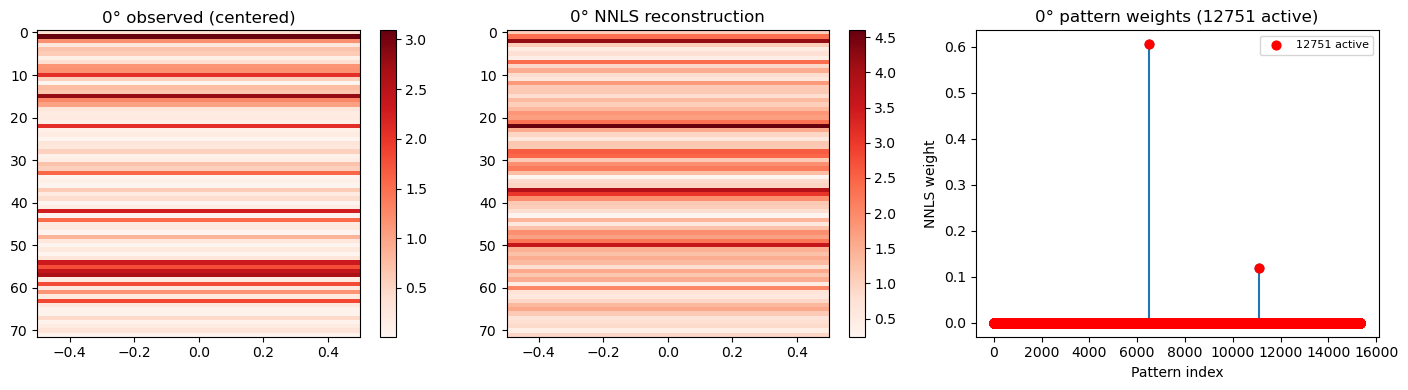

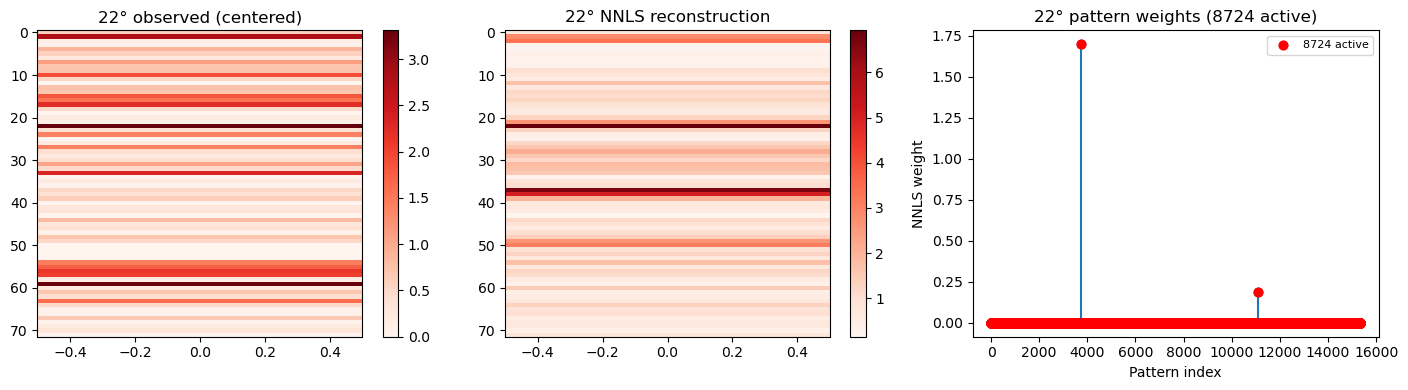

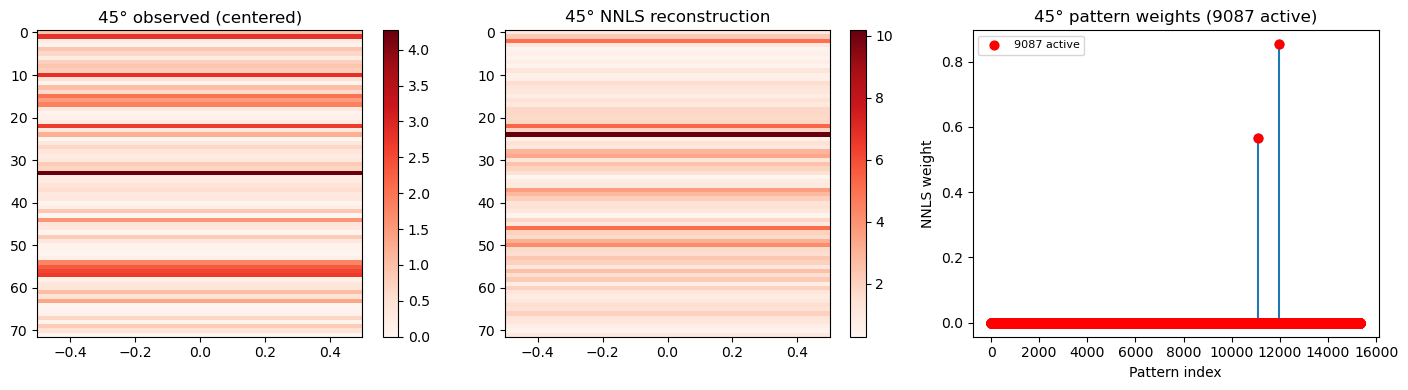

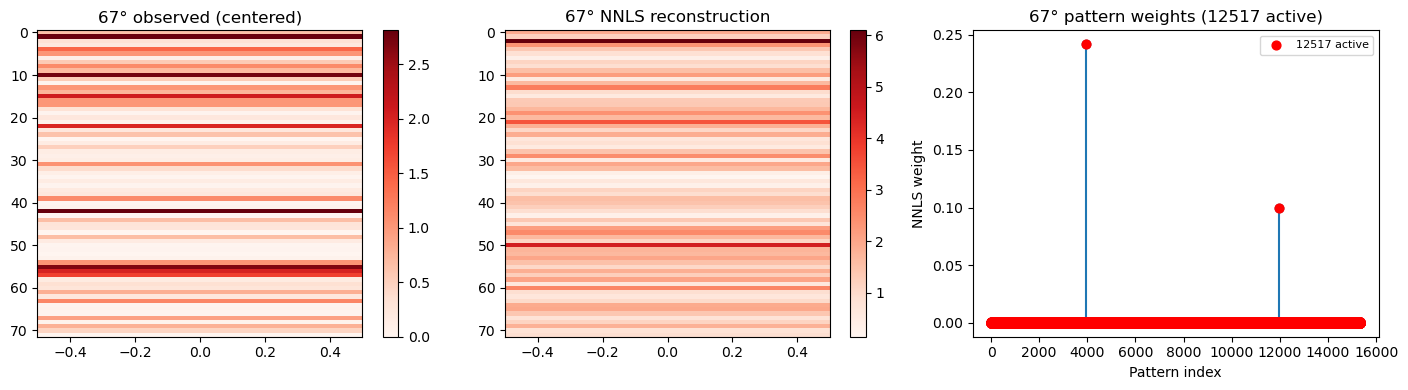

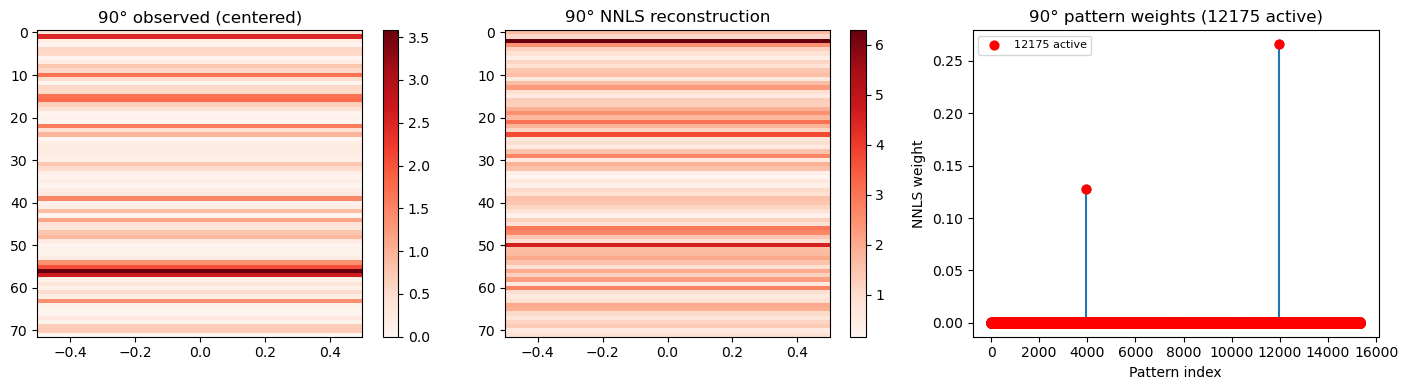

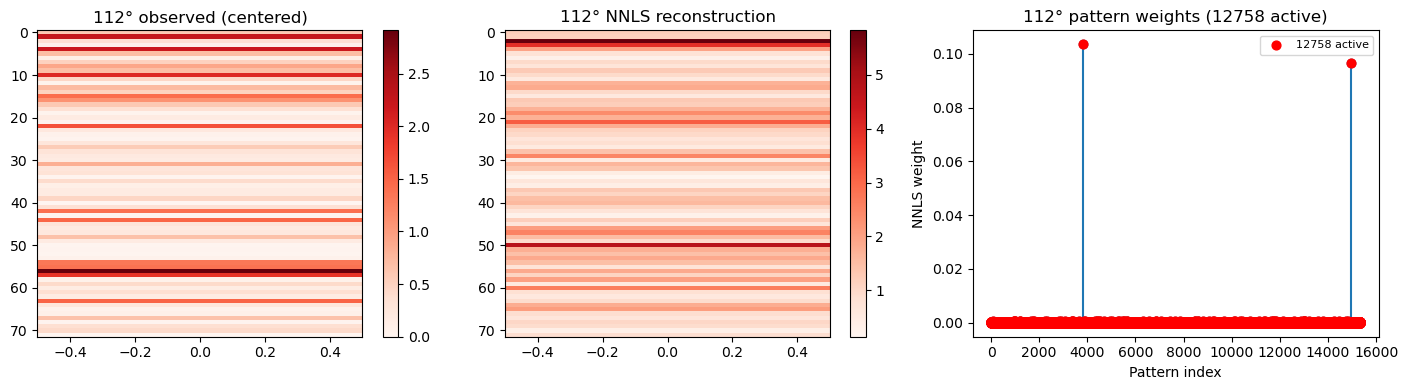

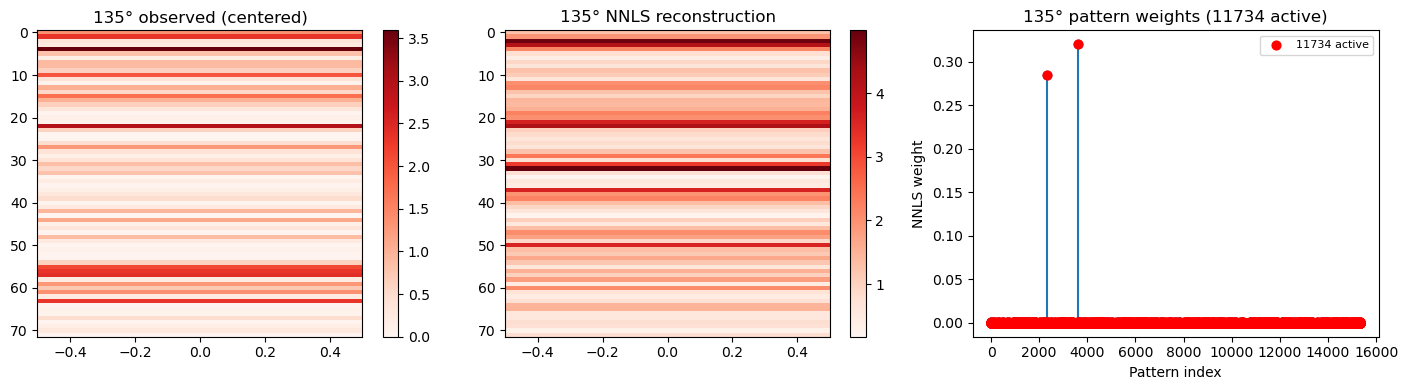

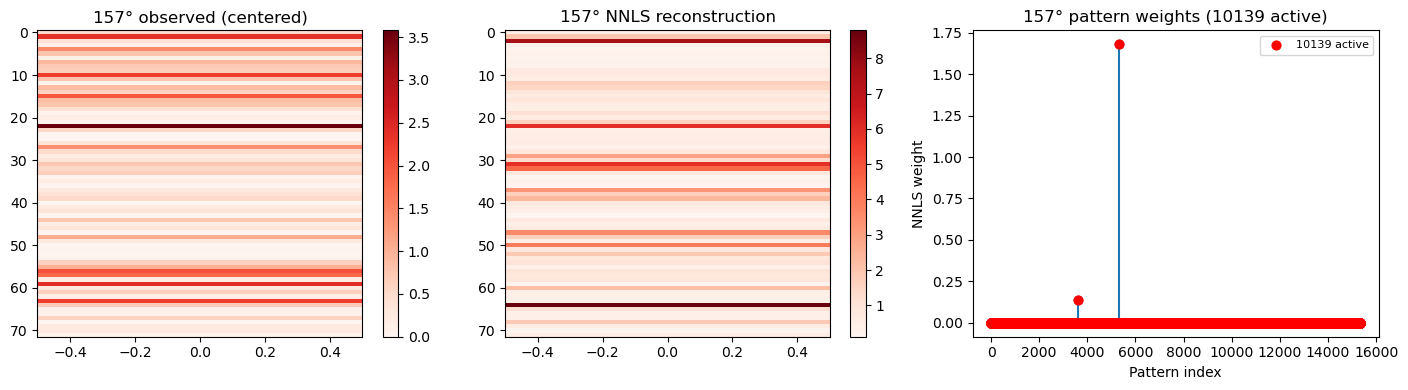

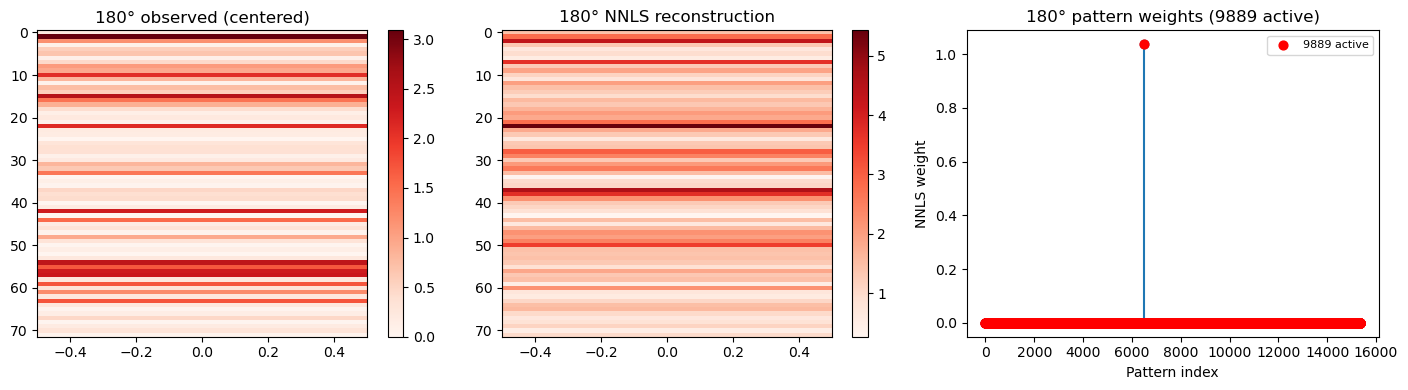

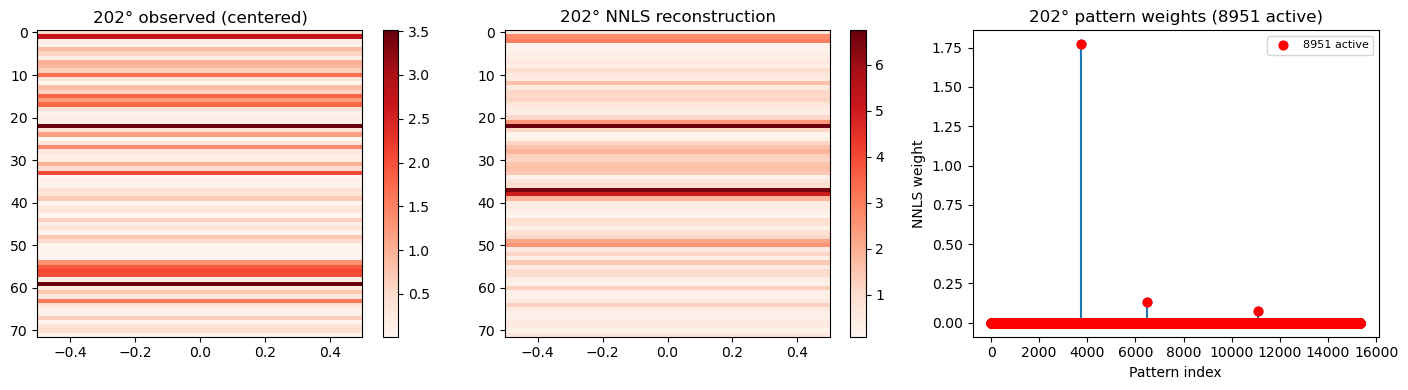

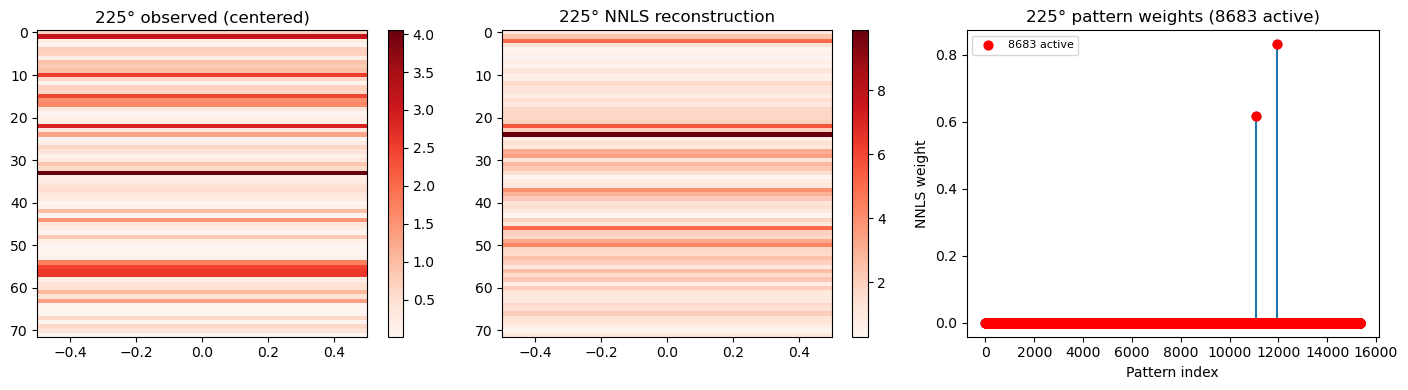

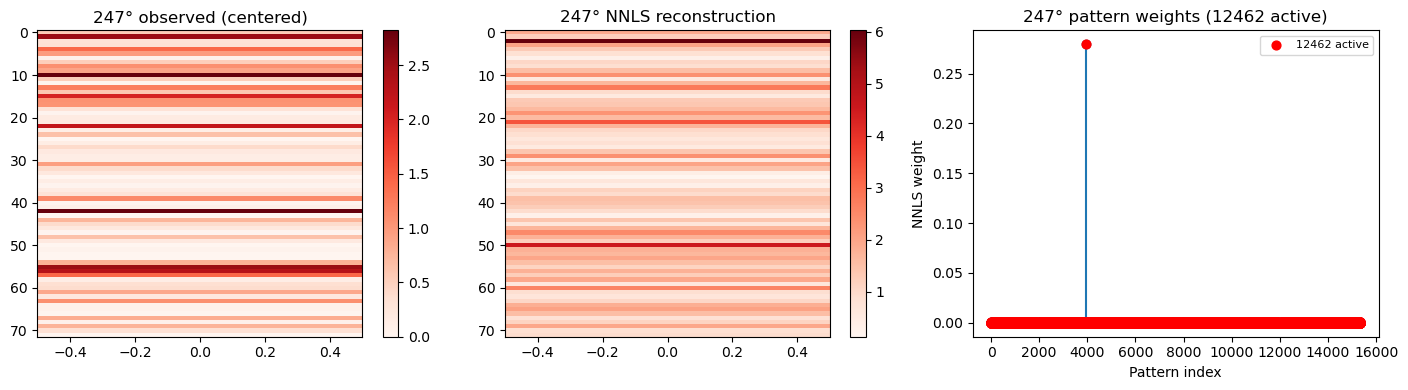

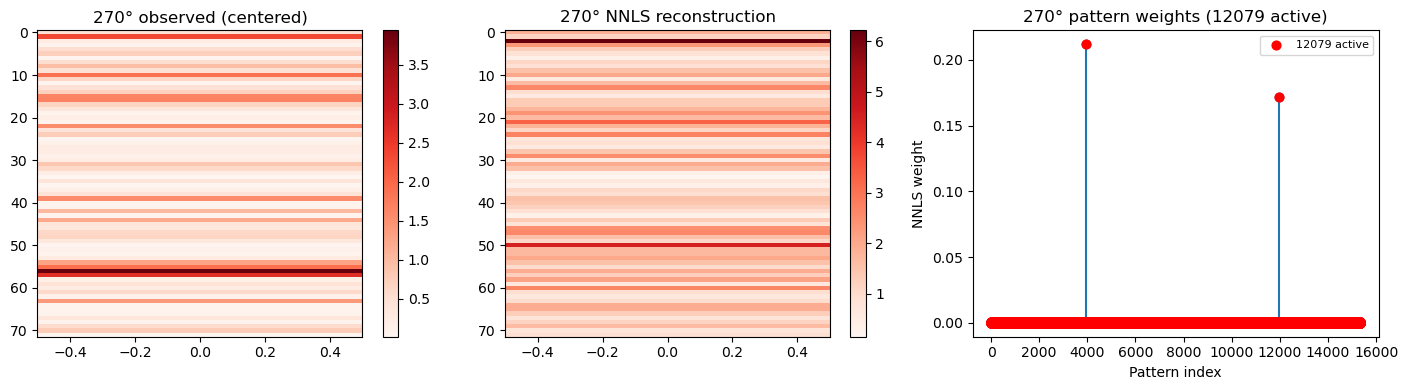

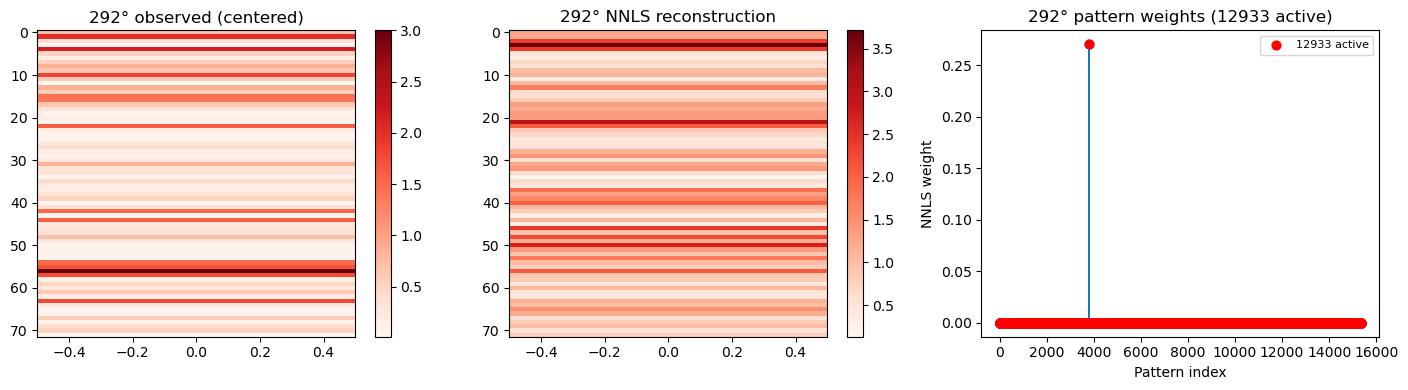

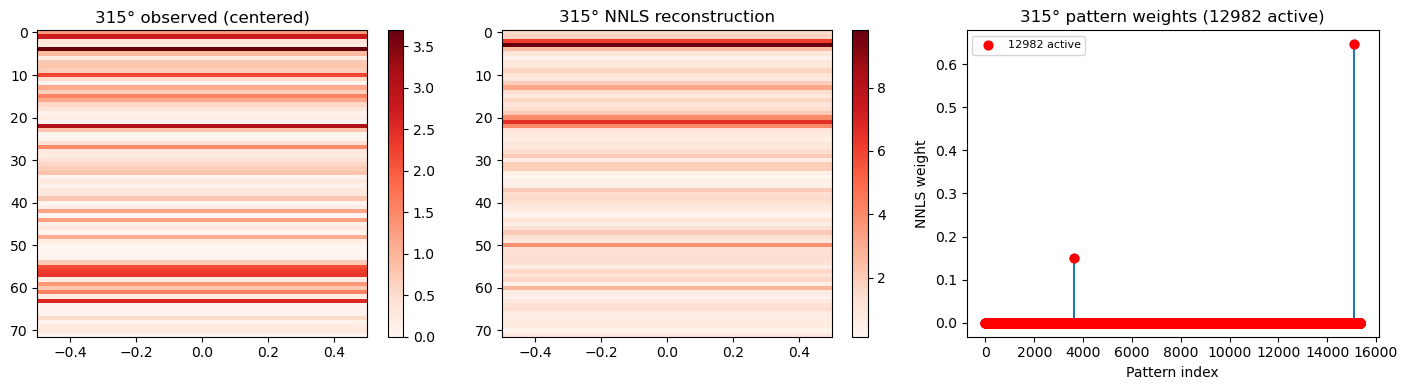

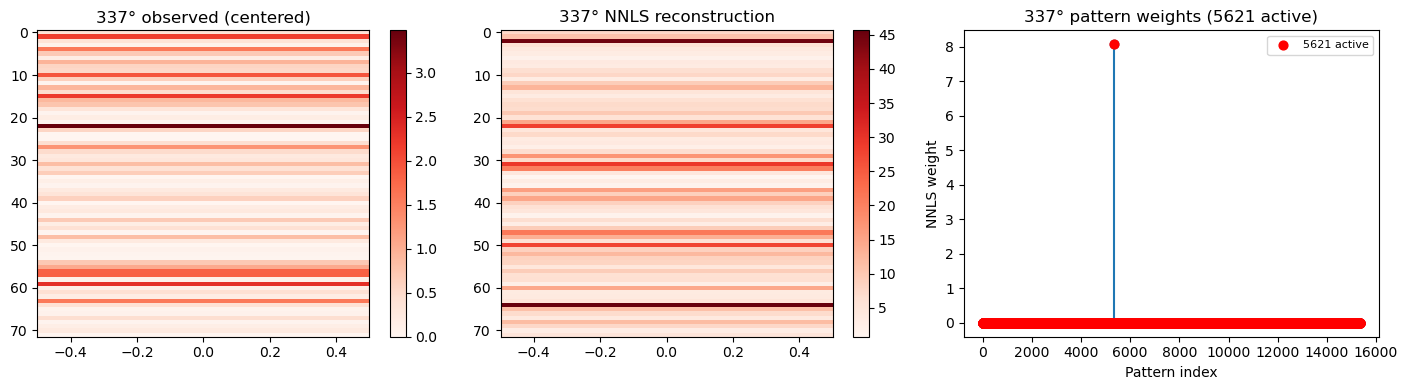

In [ ]:
for o, deg in enumerate(visual_orientation_degs):
    f, ax = plt.subplots(1, 3, figsize=(14, 4))

    # Target
    ax[0].imshow(orient_c[o].reshape(-1, 1), aspect='auto', cmap='Reds')
    ax[0].set_title(f'{int(deg)}° observed')
    plt.colorbar(ax[0].images[0], ax=ax[0])

    # NNLS reconstruction (back to centered space)
    recon_c = recon_per_orient[o]
    ax[1].imshow(recon_c.reshape(-1, 1), aspect='auto', cmap='Reds')
    ax[1].set_title(f'{int(deg)}° NNLS reconstruction')
    plt.colorbar(ax[1].images[0], ax=ax[1])

    # Pattern weights (stem plot, only nonzero entries highlighted)
    w = weights_per_orient[o]
    active = np.flatnonzero(w > 1e-6)
    ax[2].stem(np.arange(len(w)), w, basefmt=' ', linefmt='C0-', markerfmt='C0o')
    if len(active):
        ax[2].scatter(active, w[active], c='red', s=40, zorder=3, label=f'{len(active)} active')
        ax[2].legend(fontsize=8)
    ax[2].set_xlabel('Pattern index')
    ax[2].set_ylabel('NNLS weight')
    ax[2].set_title(f'{int(deg)}° pattern weights ({(w > 1e-6).sum()} active)')

    plt.tight_layout()
    plt.show()


In [101]:
import plotly.graph_objects as go

# Add the per-neuron prediction mean back so reconstructions live in the same
# uncentered space as `coords` (the observed orientation averages).
pred_mean       = pred_total.mean(axis=0)                          # (n_neurons,)
nnls_recon_full = recon_per_orient + pred_mean                     # (n_orient, n_neurons)
nnls_coords     = np.round(nnls_recon_full) @ proj                           # (n_orient, 3)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                line=dict(color='black', width=1),
                colorbar=dict(title='Orientation (°)')),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='Observed orientation avg',
))
fig.add_trace(go.Scatter3d(
    x=nnls_coords[:, 0], y=nnls_coords[:, 1], z=nnls_coords[:, 2],
    mode='markers',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                symbol='diamond', line=dict(color='white', width=1)),
    name='NNLS reconstruction',
))
for o in range(len(visual_orientation_degs)):
    fig.add_trace(go.Scatter3d(
        x=[coords[o, 0], nnls_coords[o, 0]],
        y=[coords[o, 1], nnls_coords[o, 1]],
        z=[coords[o, 2], nnls_coords[o, 2]],
        mode='lines', line=dict(color='gray', width=2, dash='dot'),
        showlegend=(o == 0), name='match link', hoverinfo='skip',
    ))
# Per-trial points overlay: low-alpha cloud showing CIS variation across trials.
trial_coords  = []
trial_doubled = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords  = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.1, line=dict(width=0)),
    name='Per-trial', hoverinfo='skip',
))



fig.update_layout(
    title='Observed orientations vs NNLS-reconstructed CNN responses',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=850, height=700,
)
fig.show()


In [ ]:
# 1. Did the fit cell rerun after the encoder fix?
print('reg.coef_:', reg.coef_.shape, '  all_stims:', train_X.shape, '  all_spikes:', train_Y.shape)
print('R^2 (linear):', np.mean(train_r2_values))

# 2. Does the model predict well on its own training data for an oracle pattern?
i = 0
print('Y true [first oracle pattern, first 5 neurons]:', train_Y[i, :5])
print('Y pred:', reg.predict(train_X)[i, :5])

# 3. What does "approx" look like vs the visual targets it's trying to hit?
print('target shape:', sum_responses[0].sum(-1).shape, 'approx shape:', approx.shape)
print('target[0] norm:', np.linalg.norm(proj.T @ sum_responses[0].sum(-1)))
print('approx[0] norm:', np.linalg.norm(approx[0]))

# 4. Distribution of coeffs after rounding
for i in range(16):
    print(f'orient {i}: round-coeffs nonzero = {(np.round(stim_coeffs[i]) > 0).sum()}, total stims = {int(np.round(stim_coeffs[i]).sum())}')


In [ ]:


fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
))


fig.add_trace(go.Scatter3d(
    x=approx[:, 0], y=approx[:, 1], z=approx[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV', symbol='diamond',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
))


fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)


In [ ]:
stim_set_per_orientation = {}
THRESH = 0.5  # min coefficient to include

# Inverse of the encoder map delay_mode_to_lridx = {-1: 0, 0: 1, 1: 2, 2: 3}
LRIDX_TO_DELAY_MODE = {0: -1, 1: 0, 2: 1, 3: 2}

for ori_idx, coeff in enumerate(stim_coeffs):
    entries = []
    if MODE == "step":
        for idx in np.where(coeff > THRESH)[0]:
            ch = idx // 4
            delay_mode = LRIDX_TO_DELAY_MODE[idx % 4]
            entries.append((int(ch), int(delay_mode), float(coeff[idx])))
    else:
        for idx in np.where(coeff > THRESH)[0]:
            ch = idx // n_amplitudes
            amp_val = -3 if (idx % n_amplitudes) == 0 else 3
            entries.append((int(ch), amp_val, float(coeff[idx])))
    entries.sort(key=lambda t: (t[0], t[1]))  # by channel, then delay_mode/amp
    stim_set_per_orientation[ori_idx] = entries


In [ ]:
for stim_set in stim_set_per_orientation.values():
    print (stim_set)    
    

In [ ]:
# ============================================================
# Build pattern registrations (inverse of read_pattern_json) from
# stim_set_per_orientation, save to generated_pattern_registration.pkl,
# and validate the structure round-trips through read_pattern_json.
#
# K_TRIALS controls how many trials per unique pattern. Each trial gets a
# distinct pattern_timing_index; trials are shuffled across the file so
# trials of the same pattern do not appear contiguously.
# ============================================================
import pickle
import copy
import itertools
import numpy as np
from collections import defaultdict, deque, Counter

if MODE != 'step':
    raise NotImplementedError('Pattern generation currently only supports MODE == step')

K_TRIALS = 10        # trials per unique pattern
SHUFFLE_SEED = 0     # for reproducibility of pattern_timing_index ordering

# Encoder writes stim_one_hot[ch*4 + delay_mode_to_lridx[delay_mode], step] = 1
# with delay_mode_to_lridx = {-1: 0, 0: 1, 1: 2, 2: 3}.  Clean inverse:
lridx_to_delay_mode = {0: -1, 1: 0, 2: 1, 3: 2}
index_to_channel = {idx: ch for ch, idx in channel_to_index.items()}
STEP_MS = 60
n_steps = MAX_TIME_MS // STEP_MS

# ---- Hardware grouping: sort real channel IDs, split into N_GROUPS equal parts.
# Each step may activate at most MAX_PER_GROUP channels from any one group.
N_GROUPS = 4
MAX_PER_GROUP = 4
sorted_real_channels = sorted(channel_to_index.keys())
# group_of[electrode_idx] = which sorted-quartile group this electrode belongs to
group_of = {}
for g in range(N_GROUPS):
    lo = (g * len(sorted_real_channels)) // N_GROUPS
    hi = ((g + 1) * len(sorted_real_channels)) // N_GROUPS
    for real_ch in sorted_real_channels[lo:hi]:
        group_of[channel_to_index[real_ch]] = g
print(f'Hardware groups (real channel IDs):')
for g in range(N_GROUPS):
    members = [c for c in sorted_real_channels if group_of[channel_to_index[c]] == g]
    print(f'  group {g}: {len(members)} channels  range=[{members[0]}, {members[-1]}]')

def feature_idx_to_ch_dm(feat_idx):
    return feat_idx // 4, lridx_to_delay_mode[feat_idx % 4]

def distribute_round_robin(items, n_steps):
    '''Place events into steps subject to:
       (1) at any step, each electrode (channel) is used at most once
           (no two encodings of the same electrode in the same step), and
       (2) at any step, at most MAX_PER_GROUP electrodes from any one
           hardware-quartile group are stimulated.
    '''
    queues = defaultdict(deque)
    for ch, dm, cnt in items:
        for _ in range(int(cnt)):
            queues[(ch, dm)].append((ch, dm))
    total = sum(len(q) for q in queues.values())
    if total == 0:
        return [[] for _ in range(n_steps)]

    # Pre-feasibility: each group has at most MAX_PER_GROUP * n_steps slots.
    group_demand = Counter()
    for (ch, dm), q in queues.items():
        group_demand[group_of[ch]] += len(q)
    for g, d in group_demand.items():
        cap = MAX_PER_GROUP * n_steps
        if d > cap:
            raise ValueError(f'group {g} requires {d} events but only {cap} slots available '
                             f'({MAX_PER_GROUP} per step x {n_steps} steps)')

    placement = [[] for _ in range(n_steps)]
    used_ch_per_step = [set() for _ in range(n_steps)]
    used_group_count = [Counter() for _ in range(n_steps)]
    last_step_for_key = {}
    placed = 0

    while placed < total:
        progressed = False
        for s in range(n_steps):
            # candidates: (ch,dm) queues that still have items, and that satisfy both constraints in this step
            candidates = []
            for k, q in queues.items():
                if not q:
                    continue
                ch = k[0]
                if ch in used_ch_per_step[s]:
                    continue                                # constraint (1)
                if used_group_count[s][group_of[ch]] >= MAX_PER_GROUP:
                    continue                                # constraint (2)
                candidates.append(k)
            if not candidates:
                continue
            # heuristic: longest queue first; break ties by max gap since last placement.
            candidates.sort(key=lambda k: (-len(queues[k]),
                                           -(s - last_step_for_key.get(k, -10**9))))
            chosen = candidates[0]
            ch, dm = chosen
            placement[s].append((ch, dm))
            used_ch_per_step[s].add(ch)
            used_group_count[s][group_of[ch]] += 1
            queues[chosen].popleft()
            last_step_for_key[chosen] = s
            placed += 1
            progressed = True
            if placed == total:
                break
        if not progressed:
            stuck = {k: len(q) for k, q in queues.items() if q}
            raise ValueError(
                f'Cannot place remaining {total - placed} events; stuck queues={stuck}. '
                f'Likely some electrode/group is over capacity even though feasibility passed -- '
                f'try increasing MAX_TIME_MS (more steps) or tightening the controller solve.'
            )
    return [
        [{'channel': int(index_to_channel[ch]), 'delay_mode': int(dm)} for (ch, dm) in placement[s]]
        for s in range(n_steps)
    ]

# Build one canonical pattern dict per orientation (no timing_index yet).
unique_patterns = []
for ori_idx, entries in stim_set_per_orientation.items():
    if any(e[1] in (-3, 3) for e in entries):
        raise NotImplementedError('stim_set_per_orientation looks like pulse-mode; rerun controller in step mode')
    items = [(int(ch), int(dm), int(round(float(cnt)))) for ch, dm, cnt in entries]
    steps_lists = distribute_round_robin(items, n_steps)
    unique_patterns.append({
        'ori_idx': int(ori_idx),
        'pattern_name': f'50{int(ori_idx)}',     # no underscore
        'steps_lists': steps_lists,
    })

# Expand to K_TRIALS copies per pattern, then shuffle to interleave trials.
rng = np.random.default_rng(SHUFFLE_SEED)
trial_slots = [(p['ori_idx'], p['pattern_name']) for p in unique_patterns for _ in range(K_TRIALS)]
order = rng.permutation(len(trial_slots))

generated_patterns = []
for new_pos, slot_idx in enumerate(order):
    ori_idx, pname = trial_slots[slot_idx]
    src = next(p for p in unique_patterns if p['ori_idx'] == ori_idx)
    steps = [
        {'index': step_idx, 'channel_delays': copy.deepcopy(cd), 'start_timestamp': 0}
        for step_idx, cd in enumerate(src['steps_lists'])
    ]
    generated_patterns.append({
        'pattern_name': pname,
        'pattern_lambda': 0.0,
        'pattern_flag_start_timestamp': 0,
        'pattern_timing_index': new_pos + 1,    # 1..N, distinct, in file order
        'steps': steps,
    })

out_path = 'data/generated_pattern_registration.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(generated_patterns, f)
print(f'Wrote {len(generated_patterns)} trials ({len(unique_patterns)} unique patterns x {K_TRIALS}) to {out_path}')

# ---- Structural validation ----
with open(f'{DATADIR}/Combined_Pattern_Registrations.pkl', 'rb') as f:
    ref = pickle.load(f)

ref_keys = set(ref[0].keys())
gen_keys = set(generated_patterns[0].keys())
assert ref_keys == gen_keys, f'top-level keys differ: ref-only={ref_keys-gen_keys}, gen-only={gen_keys-ref_keys}'
ref_step_keys = set(ref[0]['steps'][0].keys())
gen_step_keys = set(generated_patterns[0]['steps'][0].keys())
assert ref_step_keys == gen_step_keys, f'step keys differ: ref-only={ref_step_keys-gen_step_keys}, gen-only={gen_step_keys-ref_step_keys}'
def first_cd(patterns):
    for p in patterns:
        for s in p['steps']:
            if s['channel_delays']:
                return s['channel_delays'][0]
    return None
ref_cd = first_cd(ref); gen_cd = first_cd(generated_patterns)
assert ref_cd is not None and gen_cd is not None, 'no channel_delays found in one of the files'
assert set(ref_cd.keys()) == set(gen_cd.keys()), f'channel_delays keys differ: ref={set(ref_cd.keys())}, gen={set(gen_cd.keys())}'
print('[OK] schema (top / steps / channel_delays) matches Combined_Pattern_Registrations.pkl')

# ---- Sanity on timing indices and trial counts ----
timing_idxs = [p['pattern_timing_index'] for p in generated_patterns]
assert len(set(timing_idxs)) == len(timing_idxs), 'pattern_timing_index values are not distinct'
assert sorted(timing_idxs) == list(range(1, len(generated_patterns) + 1)), 'pattern_timing_index is not 1..N'
assert timing_idxs == sorted(timing_idxs), 'pattern_timing_index is not in file order'
name_counts = Counter(p['pattern_name'] for p in generated_patterns)
assert all(c == K_TRIALS for c in name_counts.values()), f'unequal trial counts per pattern: {name_counts}'

# Longest contiguous run of identical pattern_name in file order.
names_in_order = [p['pattern_name'] for p in generated_patterns]
max_run = max(len(list(g)) for _, g in itertools.groupby(names_in_order))
print(f'[OK] {len(set(timing_idxs))} distinct timing indices (1..{len(generated_patterns)}), '
      f'{K_TRIALS} trials/pattern, longest same-pattern run = {max_run}')

# ---- Hardware-constraint validation: per-step, per-channel and per-group limits.
for p in generated_patterns:
    for s in p['steps']:
        ch_counts = Counter(cd['channel'] for cd in s['channel_delays'])
        if any(v > 1 for v in ch_counts.values()):
            raise AssertionError(f'pattern {p["pattern_name"]} step {s["index"]}: '
                                 f'electrode used multiple times: {ch_counts}')
        grp_counts = Counter(group_of[channel_to_index[cd['channel']]] for cd in s['channel_delays'])
        for g, c in grp_counts.items():
            if c > MAX_PER_GROUP:
                raise AssertionError(f'pattern {p["pattern_name"]} step {s["index"]}: '
                                     f'group {g} used {c} times (max {MAX_PER_GROUP})')
print(f'[OK] hardware constraints: <=1 encoding per electrode per step, '
      f'<={MAX_PER_GROUP} channels per group per step')

# ---- read_pattern_json round-trip ----
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
from utils import read_pattern_json
rt_df = read_pattern_json(out_path)
print(f'[OK] read_pattern_json round-trip: {rt_df.shape[0]} rows, '
      f'{rt_df["pattern_timing_index"].nunique()} timing indices, '
      f'{rt_df["pattern_name"].nunique()} unique patterns')

# ---- Per-pattern (electrode, delay_mode) count preservation ----
for ori_idx, entries in stim_set_per_orientation.items():
    expected = Counter()
    for ch, dm, cnt in entries:
        expected[(int(ch), int(dm))] += int(round(float(cnt)))
    expected = Counter({k: v for k, v in expected.items() if v > 0})
    pname = f'50{int(ori_idx)}'
    sample = next(p for p in generated_patterns if p['pattern_name'] == pname)
    rebuilt = Counter()
    for s in sample['steps']:
        for cd in s['channel_delays']:
            ch_idx = channel_to_index[cd['channel']]
            rebuilt[(ch_idx, cd['delay_mode'])] += 1
    assert expected == rebuilt, f'pattern {pname}: expected={expected}  rebuilt={rebuilt}'
print(f'[OK] (electrode, delay_mode) counts preserved across all {len(stim_set_per_orientation)} unique patterns')


In [ ]:
rt_df.head(50)


In [ ]:
# ============================================================
# Visualize one example: stim_set vector (160 features x count) vs.
# the generated pattern's per-step channel x delay_mode train.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

EXAMPLE_ORI = 0   # which orientation/pattern to visualize
DM_TO_LRIDX = {-1: 0, 0: 1, 1: 2, 2: 3}

entries = stim_set_per_orientation[EXAMPLE_ORI]
pat = generated_patterns[EXAMPLE_ORI]

# 1. Build the 160-d feature vector with integer counts (post-rounding). Use += in case
#    the same (ch, dm) appears more than once in entries.
feat_vec = np.zeros(n_stim_channels * 4, dtype=int)
n_skipped_entries = 0
for ch, dm, cnt in entries:
    lridx = DM_TO_LRIDX.get(int(dm))
    if lridx is None:
        n_skipped_entries += 1
        continue
    feat_vec[int(ch) * 4 + lridx] += int(round(float(cnt)))
if n_skipped_entries:
    print(f'[warn] skipped {n_skipped_entries} entries with unknown delay_mode '
          f'(stale stim_set_per_orientation? rerun the build cell)')

# 2. Build the (n_features, n_steps) train from the generated pattern.
train = np.zeros((n_stim_channels * 4, n_steps), dtype=int)
n_skipped_train = 0
for s_idx, s in enumerate(pat['steps']):
    for cd in s['channel_delays']:
        lridx = DM_TO_LRIDX.get(cd['delay_mode'])
        if lridx is None:
            n_skipped_train += 1
            continue
        ch_idx = channel_to_index[cd['channel']]
        train[ch_idx * 4 + lridx, s_idx] += 1
if n_skipped_train:
    print(f'[warn] skipped {n_skipped_train} pattern entries with unknown delay_mode')

# Sanity (warn rather than assert, so the figure still renders if there's a mismatch).
if not np.array_equal(train.sum(axis=1), feat_vec):
    diff = np.where(train.sum(axis=1) != feat_vec)[0]
    print(f'[warn] train rowsum != feat_vec at {len(diff)} indices  '
          f'(feat_sum={feat_vec.sum()}, train_sum={train.sum()}). First few: {diff[:5]}')

# Per-electrode timeline: rows = electrodes, cols = steps, value = delay_mode used (NaN if empty).
per_ch = np.full((n_stim_channels, n_steps), np.nan)
for s_idx, s in enumerate(pat['steps']):
    for cd in s['channel_delays']:
        per_ch[channel_to_index[cd['channel']], s_idx] = cd['delay_mode']

fig, ax = plt.subplots(3, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [1, 2, 3]})
fig.suptitle(f'Generated pattern for orientation idx {EXAMPLE_ORI} '
             f'(deg = {visual_orientation_degs[EXAMPLE_ORI]})')

# (0) feature-vector bar plot
ax[0].bar(np.arange(len(feat_vec)), feat_vec, width=1.0, color='steelblue', edgecolor='none')
for c in range(1, n_stim_channels):
    ax[0].axvline(c * 4 - 0.5, color='k', alpha=0.1, linewidth=0.5)
ax[0].set_xlim(-0.5, len(feat_vec) - 0.5)
ax[0].set_xlabel('Feature idx (electrode * 4 + lridx)')
ax[0].set_ylabel('Count')
ax[0].set_title(f'stim_set vector — {int(feat_vec.sum())} total events across '
                f'{int((feat_vec > 0).sum())} (electrode, delay_mode) slots')

# (1) per-electrode timeline
cmap = plt.cm.get_cmap('tab10', 4)
im_e = ax[1].imshow(per_ch, aspect='auto', interpolation='nearest',
                    cmap=cmap, vmin=-1.5, vmax=2.5)
ax[1].set_xlabel(f'Step idx (each step = {STEP_MS} ms)')
ax[1].set_ylabel('Electrode idx')
n_active_electrodes = int((~np.isnan(per_ch)).any(axis=1).sum())
ax[1].set_title(f'Per-electrode stim timeline  ({n_active_electrodes} electrodes used)')
cb_e = plt.colorbar(im_e, ax=ax[1], ticks=[-1, 0, 1, 2])
cb_e.set_label('Delay mode')

# (2) feature-level train (160 x n_steps)
im = ax[2].imshow(np.where(train > 0, train, np.nan), aspect='auto',
                  interpolation='nearest', cmap='viridis')
ax[2].set_xlabel(f'Step idx (each step = {STEP_MS} ms)')
ax[2].set_ylabel('Feature idx (electrode * 4 + lridx)')
ax[2].set_title(f'Per-step pattern train  shape={train.shape}')
for c in range(1, n_stim_channels):
    ax[2].axhline(c * 4 - 0.5, color='k', alpha=0.1, linewidth=0.3)
plt.colorbar(im, ax=ax[2], label='Event present')

plt.tight_layout()
plt.show()

# Textual step-by-step printout.
print(f'\nPattern timing_index={pat["pattern_timing_index"]}, n_steps={len(pat["steps"])}')
for s in pat['steps']:
    cds = s['channel_delays']
    desc = ', '.join(f"ch{cd['channel']}/dm{cd['delay_mode']}" for cd in cds) if cds else '(empty)'
    print(f'  step {s["index"]:>2}: {desc}')


In [ ]:
diff_idx = np.where(train.sum(axis=1) != feat_vec)[0]
print('mismatched feat indices:', diff_idx)
for i in diff_idx[:10]:
    ch, lridx = i // 4, i % 4
    print(f'  feat[{i}] (ch={ch}, lridx={lridx}): feat_vec={feat_vec[i]}, train_rowsum={train.sum(axis=1)[i]}')
print()
print('entries for example pattern:', entries)
print('total feat_vec sum:', feat_vec.sum(), ' train sum:', train.sum())


In [ ]:
# ============================================================
# Per-timestep STA from non-oracle trials.
# For each unique 160-d simultaneous-stim vector seen in any non-oracle trial step,
# collect the per-neuron spike counts in a [STA_START, STA_END) window relative to
# the step's start time, and average across every (trial, step) where it appeared.
# ============================================================
import numpy as np
from collections import defaultdict

STEP_MS = 60
STA_START = 0       # ms offset from step start where the response window begins
STA_END   = 60      # ms offset from step start where the response window ends (exclusive)

assert STA_END > STA_START, 'STA_END must be > STA_START'

step_key_to_spikes = defaultdict(list)   # tuple(160,) -> list of (n_neurons,) spike-count arrays
step_key_to_count = defaultdict(int)     # tuple -> # occurrences

delay_mode_to_lridx = {-1: 0, 0: 1, 1: 2, 2: 3}

for timing_idx in spike_responses.keys():
    spk   = spike_responses[timing_idx]         # (n_neurons, T_ms)
    pname = timing_to_pattern[timing_idx]
    stim  = pattern_stims[pname]
    pol   = pattern_polarities[pname]
    signed_stim = stim * pol                    # (n_channels, T_ms)
    T = signed_stim.shape[1]
    n_steps = T // STEP_MS

    # Build (160, n_steps) one-hot for this trial.
    stim_one_hot = np.zeros((n_stim_channels * 4, n_steps), dtype=np.int8)
    for step in range(0, T, STEP_MS):
        for ch in range(n_stim_channels):
            dm = None
            # dm=2: 100Hz anodic; both step and step+10 are +3.
            if signed_stim[ch, step] == 3 and signed_stim[ch, step + 10] == 3:
                dm = 2
            # dm=0: 50Hz anodic, +3 at step start, step+10 empty.
            elif signed_stim[ch, step] == 3:
                dm = 0
            # dm=1: 50Hz anodic, delayed 10ms.
            elif signed_stim[ch, step + 10] == 3:
                dm = 1
            # dm=-1: 50Hz cathodic.
            elif signed_stim[ch, step] == -3:
                dm = -1
            if dm is not None:
                stim_one_hot[ch * 4 + delay_mode_to_lridx[dm], step // STEP_MS] = 1

    for s in range(n_steps):
        key = tuple(stim_one_hot[:, s].tolist())
        if sum(key) == 0:
            continue                            # skip empty steps
        lo = s * STEP_MS + STA_START
        hi = s * STEP_MS + STA_END
        if hi > spk.shape[1] or lo < 0:
            continue                            # window would run off the trial
        spike_count = spk[:, lo:hi].sum(axis=1) # (n_neurons,)
        step_key_to_spikes[key].append(spike_count)
        step_key_to_count[key] += 1

# Sort by occurrence frequency (descending), then by # simultaneous stims (descending).
unique_keys = sorted(
    step_key_to_spikes.keys(),
    key=lambda k: (-step_key_to_count[k], -sum(k)),
)
sta_matrix = np.stack([
    np.mean(step_key_to_spikes[k], axis=0) for k in unique_keys
])                                                       # (n_unique_steps, n_neurons)
sta_keys = np.array(unique_keys, dtype=np.int8)          # (n_unique_steps, 160)
n_simul = sta_keys.sum(axis=1)                            # (n_unique_steps,)
n_occurrences = np.array([step_key_to_count[k] for k in unique_keys])

print(f'STA window: [{STA_START}, {STA_END}) ms relative to step start  ({STA_END - STA_START} ms)')
print(f'unique simultaneous-stim vectors observed: {len(unique_keys)}')
print(f'occurrence counts:  min={n_occurrences.min()}, '
      f'median={np.median(n_occurrences):.0f}, max={n_occurrences.max()}')
print(f'# simultaneous stims per vector:  min={n_simul.min()}, '
      f'median={np.median(n_simul):.1f}, max={n_simul.max()}')
print(f'sta_matrix shape: {sta_matrix.shape}')


In [ ]:
# ============================================================
# Linearity check: is the STA of a multi-stim step approximately the SUM
# of the STAs of its individual stims?
#
# For each multi-stim key k (with K active features), compute:
#   predicted = sum_{f in active(k)} single_feat_sta[f]
#   observed  = sta_matrix[row(k)]
# then plot predicted vs. observed across (key, neuron).
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# 1) Build a per-feature single-stim STA: average response across all keys whose only
#    active bit is feature f. If a feature was never seen alone, it has no entry.
single_feat_sta = {}                      # feat_idx -> (n_neurons,)
for k, sta in zip(unique_keys, sta_matrix):
    if sum(k) == 1:
        f = int(np.argmax(k))
        single_feat_sta[f] = sta

print(f'features observed alone: {len(single_feat_sta)} / 160')

# 2) For multi-stim keys whose every active feature was also observed alone, predict
#    by summation and compare to the observed STA.
multi_keys = [k for k in unique_keys if sum(k) > 1]
predictable_idx = []
predicted_rows = []
observed_rows = []
ks_used = []
for k_idx, k in enumerate(unique_keys):
    if sum(k) <= 1:
        continue
    active = np.where(np.array(k) == 1)[0]
    if not all(f in single_feat_sta for f in active):
        continue
    pred = sum(single_feat_sta[f] for f in active)
    predictable_idx.append(k_idx)
    predicted_rows.append(pred)
    observed_rows.append(sta_matrix[k_idx])
    ks_used.append(k)
predicted = np.array(predicted_rows)      # (n_predictable, n_neurons)
observed  = np.array(observed_rows)
print(f'multi-stim keys with all components seen alone: {len(predicted_rows)} / {len(multi_keys)}')

# 3) Scatter (one point per (key, neuron)) and per-neuron correlation.
if predicted.size:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    p_flat = predicted.flatten()
    o_flat = observed.flatten()
    ax[0].scatter(p_flat, o_flat, alpha=0.15, s=8, edgecolor='none')
    lim = max(p_flat.max(), o_flat.max())
    ax[0].plot([0, lim], [0, lim], 'k--', alpha=0.5, label='y = x (linear)')
    ax[0].set_xlabel('Predicted (sum of single-stim STAs)')
    ax[0].set_ylabel('Observed multi-stim STA')
    r = np.corrcoef(p_flat, o_flat)[0, 1]
    ax[0].set_title(f'Linearity check  (overall pearson r = {r:.3f})')
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    # Per-neuron correlation across keys.
    per_neuron_r = np.array([
        np.corrcoef(predicted[:, n], observed[:, n])[0, 1] if predicted[:, n].std() > 0 else np.nan
        for n in range(observed.shape[1])
    ])
    ax[1].hist(per_neuron_r[~np.isnan(per_neuron_r)], bins=20, color='steelblue', edgecolor='k')
    ax[1].axvline(np.nanmean(per_neuron_r), color='r', linestyle='--',
                  label=f'mean r = {np.nanmean(per_neuron_r):.3f}')
    ax[1].set_xlabel('Per-neuron pearson r (observed vs. predicted)')
    ax[1].set_ylabel('# neurons')
    ax[1].set_title('Per-neuron linearity')
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('no multi-stim keys had all components observed alone -- cannot test linearity from this dataset.')


In [ ]:
# ============================================================
# Per-feature response heatmap (160 features x n_neurons).
# Row f = mean spike response over every (trial, step) where feature f was active,
# regardless of which other features were co-active. Shows how spatially localized
# each (electrode, delay_mode) effect is.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Re-walk non-oracle trials, accumulating spike counts per active feature.
STEP_MS = 60
delay_mode_to_lridx = {-1: 0, 0: 1, 1: 2, 2: 3}
n_features = n_stim_channels * 4

feat_spike_sum = np.zeros((n_features, n_neurons), dtype=float)
feat_count = np.zeros(n_features, dtype=int)

for timing_idx in spike_responses.keys():
    if timing_idx in test_indices:
        continue

    spk = spike_responses[timing_idx]
    pname = timing_to_pattern[timing_idx]
    stim = pattern_stims[pname]
    pol  = pattern_polarities[pname]
    signed_stim = stim * pol
    T = signed_stim.shape[1]
    n_steps = T // STEP_MS

    stim_one_hot = np.zeros((n_features, n_steps), dtype=np.int8)
    for step in range(0, T, STEP_MS):
        for ch in range(n_stim_channels):
            dm = None
            # dm=2: 100Hz anodic; both step and step+10 are +3.
            if signed_stim[ch, step] == 3 and signed_stim[ch, step + 10] == 3:
                dm = 2
            # dm=0: 50Hz anodic, +3 at step start, step+10 empty.
            elif signed_stim[ch, step] == 3:
                dm = 0
            # dm=1: 50Hz anodic, delayed 10ms.
            elif signed_stim[ch, step + 10] == 3:
                dm = 1
            # dm=-1: 50Hz cathodic.
            elif signed_stim[ch, step] == -3:
                dm = -1
            if dm is not None:
                stim_one_hot[ch * 4 + delay_mode_to_lridx[dm], step // STEP_MS] = 1

    for s in range(n_steps):
        active = np.where(stim_one_hot[:, s] == 1)[0]
        if active.size == 0:
            continue
        lo = s * STEP_MS + STA_START
        hi = s * STEP_MS + STA_END
        if hi > spk.shape[1] or lo < 0:
            continue
        spike_count = spk[:, lo:hi].sum(axis=1)         # (n_neurons,)
        for f in active:
            feat_spike_sum[f] += spike_count
            feat_count[f] += 1

# Mean response per feature (NaN if feature never seen).
with np.errstate(invalid='ignore', divide='ignore'):
    feat_response = feat_spike_sum / feat_count[:, None]
feat_response[feat_count == 0] = np.nan

# Reorder neuron columns by overall mean responsiveness (global ordering).
overall = np.nanmean(feat_response, axis=0)
neuron_order = np.argsort(-overall)
heatmap = feat_response[:, neuron_order]

fig, ax = plt.subplots(figsize=(10, 12))
vmax = np.nanpercentile(heatmap, 99) if np.any(~np.isnan(heatmap)) else 1.0
im = ax.imshow(heatmap, aspect='auto', interpolation='nearest', cmap='magma',
               vmin=0, vmax=vmax)
ax.set_xlabel('Neuron (sorted by mean response)')
ax.set_ylabel('Feature idx (electrode * 4 + lridx)')
ax.set_title(f'Mean spike count per feature  '
             f'(STA window [{STA_START}, {STA_END}) ms)')
for c in range(1, n_stim_channels):
    ax.axhline(c * 4 - 0.5, color='w', alpha=0.15, linewidth=0.3)
plt.colorbar(im, ax=ax, label='Mean spike count')
plt.tight_layout()
plt.show()

print(f'\nFeatures observed: {(feat_count > 0).sum()} / {n_features}')
print(f'Occurrence counts: min={feat_count[feat_count>0].min()}, '
      f'median={int(np.median(feat_count[feat_count>0]))}, '
      f'max={feat_count.max()}')


In [ ]:
print('features with zero count:', int((feat_count == 0).sum()), '/', n_features)
print('features by count buckets:')
for lo, hi in [(0,1), (1,10), (10,100), (100,1000), (1000, 10000), (10000, 1e9)]:
    n = ((feat_count >= lo) & (feat_count < hi)).sum()
    print(f'  [{lo}, {hi}):  {n} features')

# Per-electrode summary: which delay modes fired at all?
for ch in range(n_stim_channels):
    counts = feat_count[ch*4:(ch+1)*4]
    if counts.sum() == 0:
        print(f'  ch {ch}: NEVER stimulated')
    elif (counts == 0).any():
        modes = ['-1', '0', '1', '2']
        active = [m for m, c in zip(modes, counts) if c > 0]
        print(f'  ch {ch}: only modes {active} active, counts={counts.tolist()}')



In [ ]:
# Diagnostic A: does the raw pickle contain delay_mode=2 anywhere?
import pickle
ref = pickle.load(open('data/Combined_Pattern_Registrations.pkl', 'rb'))
dm_counts = {}
for p in ref:
    for s in p['steps']:
        for cd in s['channel_delays']:
            dm_counts[cd['delay_mode']] = dm_counts.get(cd['delay_mode'], 0) + 1
print('delay_mode counts in raw pickle:', dm_counts)

# Diagnostic B: does pattern_stims/polarities encode dm=2 as a -3,+3 pair?
# Walk a handful of patterns and look for the (-3, +3 at +10ms) signature.
import numpy as np
hits = 0
for pname in list(pattern_stims.keys())[:200]:
    s = pattern_stims[pname] * pattern_polarities[pname]
    for ch in range(n_stim_channels):
        for t in range(0, s.shape[1] - 10, 60):
            if s[ch, t] == -3 and s[ch, t+10] == 3:
                hits += 1
                break
        else:
            continue
        break
print(f'patterns with at least one (-3 @ t, +3 @ t+10) pair in first 200 patterns:', hits)
